In [1]:
# - Librairies -----
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from nucleo.io.reading import reading_all_parquet

In [2]:
# - Getting the data -----
root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-05-21"
root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-09-17"

df_fact = reading_all_parquet(root_fact)
df_fact.group_by(["mode", "land", "l", "alphar", "Kp"])
print(df_fact)

/home/nicolas/Documents/Workspace/nucleo/src/nucleo/io/reading.py:143: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = _scalar_column_names(lf.schema)


shape: (3_564, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 90.5  ┆ 9.596559 ┆ 6.89349  ┆ 1.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 90.5  ┆ 5.28071  ┆ 3.85463  ┆ 1.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 90.5  ┆ 0.996721 ┆ 0.834717 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 90.5  ┆ 9.566036 ┆ 6.890831 ┆ 2.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 90.5  ┆ 5.22213  ┆ 3.821023 ┆ 1.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 258.5 ┆ 5.268766 ┆ 3.813622 ┆ 1.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 264.5 ┆ 0.997682 ┆

# Passive

In [3]:
# - Data -----
df_passive = df_fact.filter(pl.col("mode") == "passfull")
print(df_passive)
print(df_passive.columns)

shape: (1_188, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 90.5  ┆ 9.646909 ┆ 6.88635  ┆ 1.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 90.5  ┆ 5.275333 ┆ 3.847067 ┆ 1.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 90.5  ┆ 0.998078 ┆ 0.836535 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 89.5  ┆ 9.511451 ┆ 6.736914 ┆ 1.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 90.5  ┆ 5.252448 ┆ 3.831714 ┆ 1.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 258.5 ┆ 5.268766 ┆ 3.813622 ┆ 1.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 264.5 ┆ 0.997682 ┆

In [10]:
columns = [
    'algo', 'fact', 'mode', 'dstr', 
    'land', 's', 'l', 'bpmin', 
    'mu', 'theta', 'alphaf', 
    'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 
    'alphar', 'krel', 'Kp', 'Kz'
]

for col in columns:
    print(f"Unique values of {col} : {np.unique(df_passive[col])}")

mu          = 150
theta       = 100
rrest       = 2.0
Kz          = 0.0

df_passive = df_passive.filter(
    (pl.col("mu") == mu) &
    (pl.col("theta") == theta) &
    (pl.col("rrest") == rrest) &
    (pl.col("Kz") == Kz)
)

print(df_passive)

Unique values of algo : ['2S']
Unique values of fact : [ True]
Unique values of mode : ['passfull']
Unique values of dstr : [False]
Unique values of land : ['periodic' 'random']
Unique values of s : [35]
Unique values of l : [ 10  35 100]
Unique values of bpmin : [0]
Unique values of mu : [150]
Unique values of theta : [100]
Unique values of alphaf : [1.]
Unique values of alphao : [0.]
Unique values of beta : [0.]
Unique values of rcapt : [2.]
Unique values of rrest : [0.1 0.2 2. ]
Unique values of alphac : [0.67]
Unique values of alphad : [0.]
Unique values of alphar : [0.]
Unique values of krel : [1.]
Unique values of Kp : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Unique values of Kz : [0.]
shape: (66, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ 

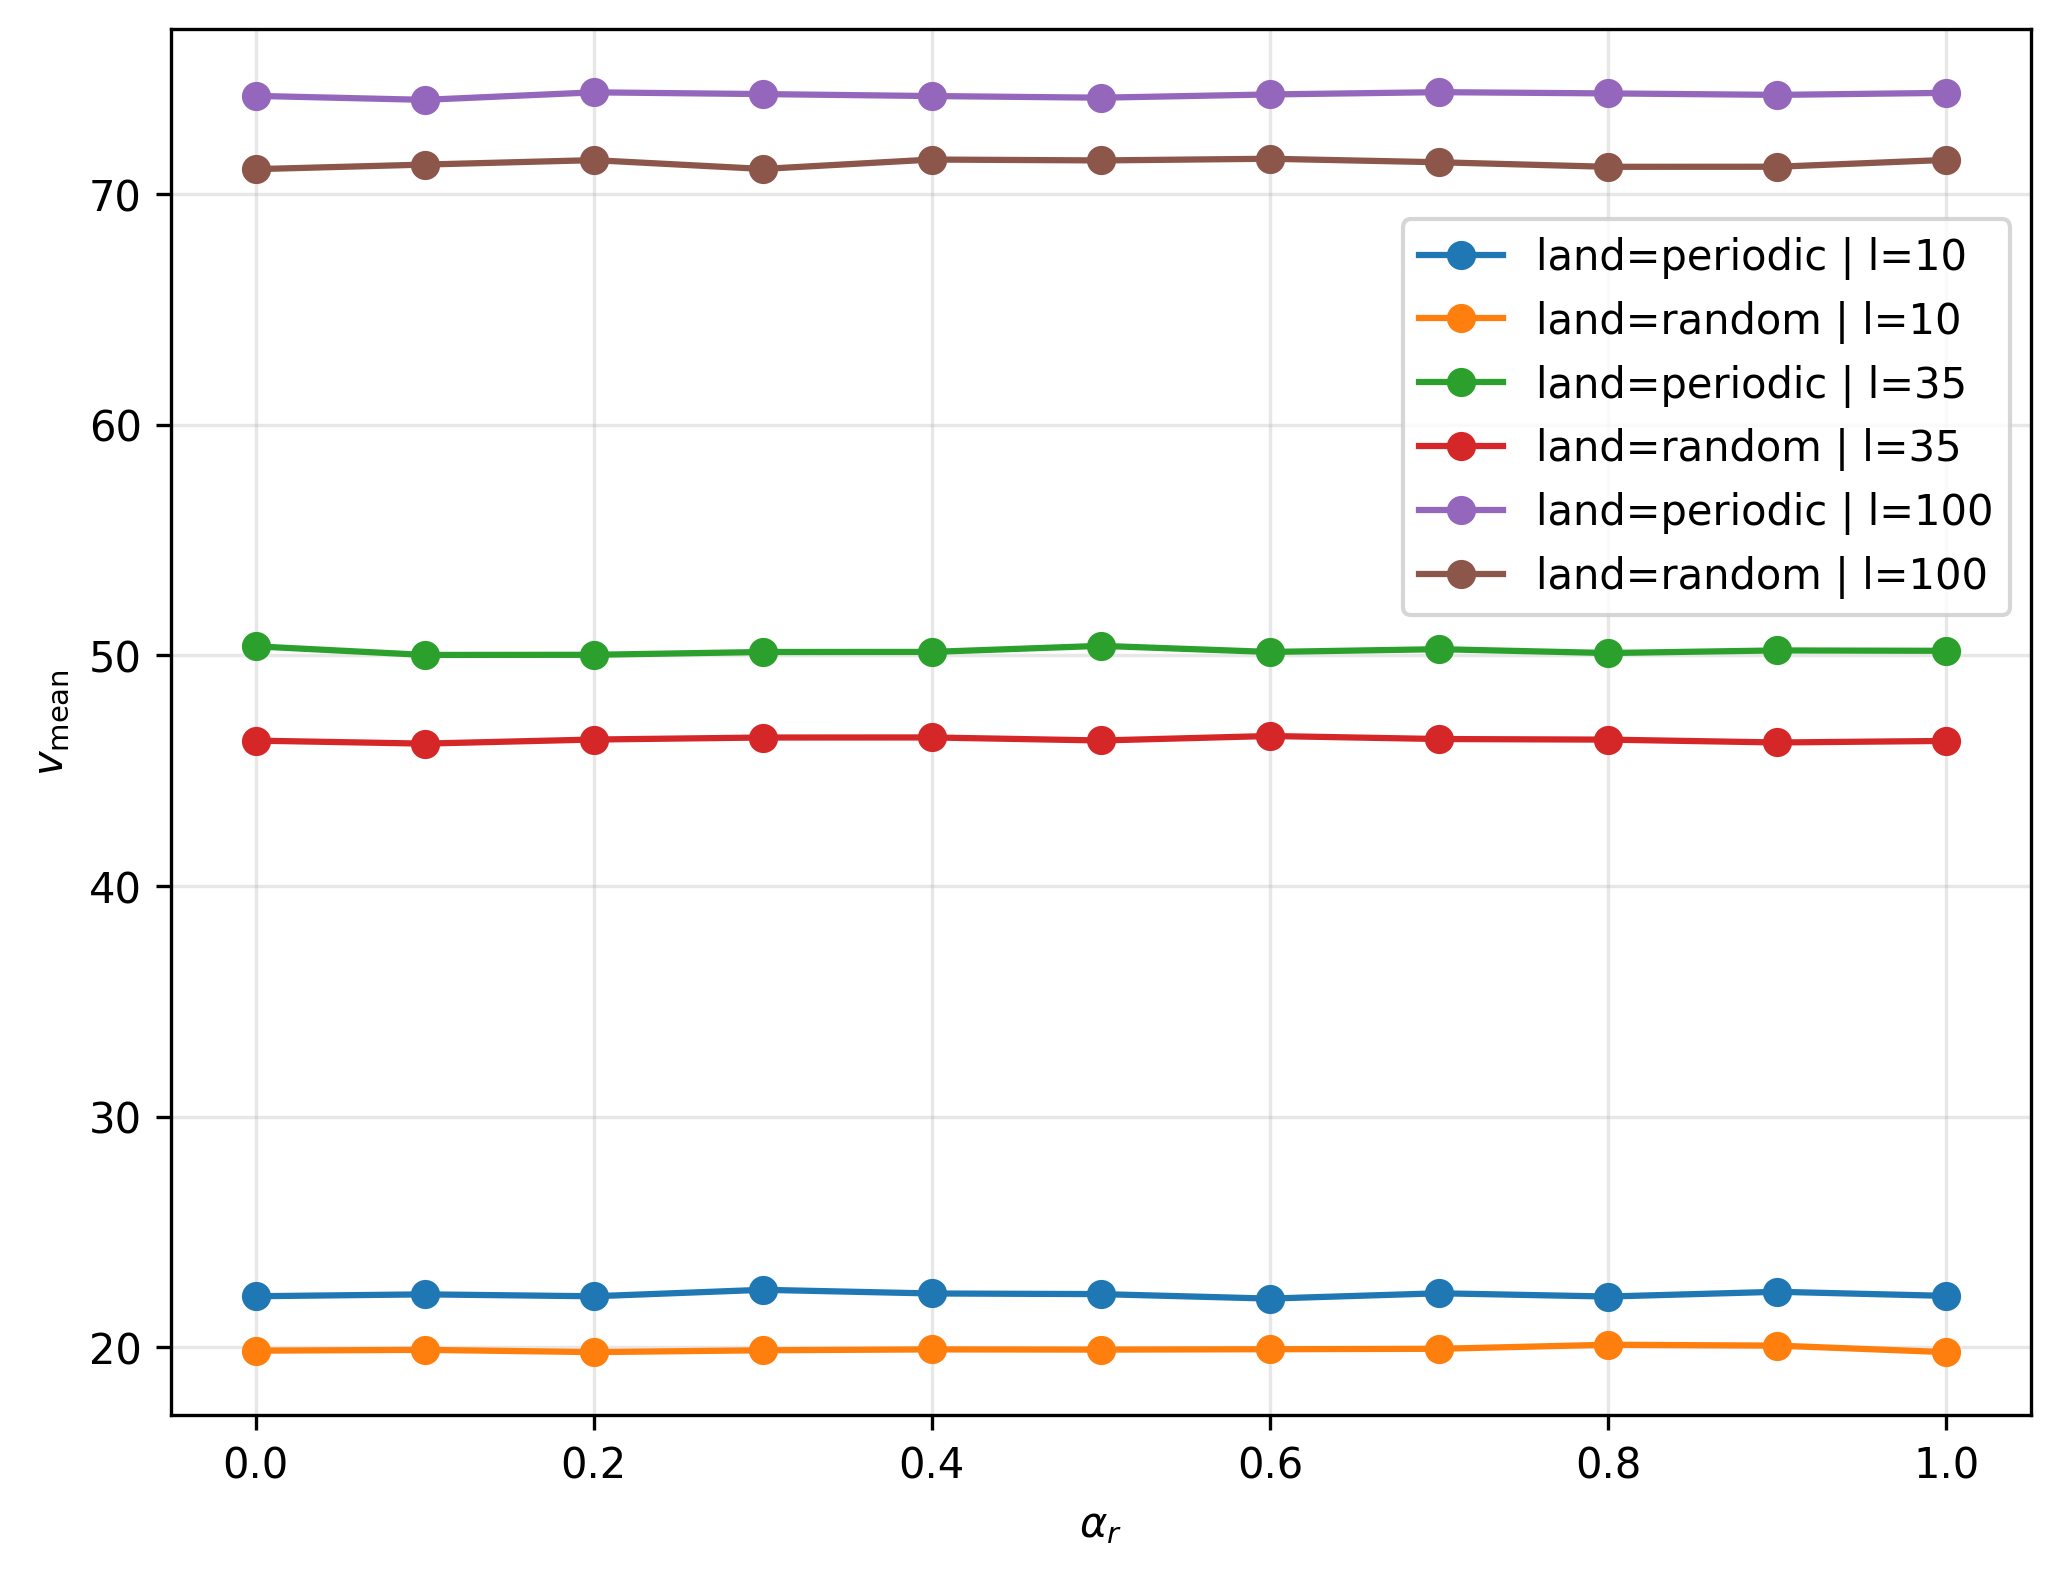

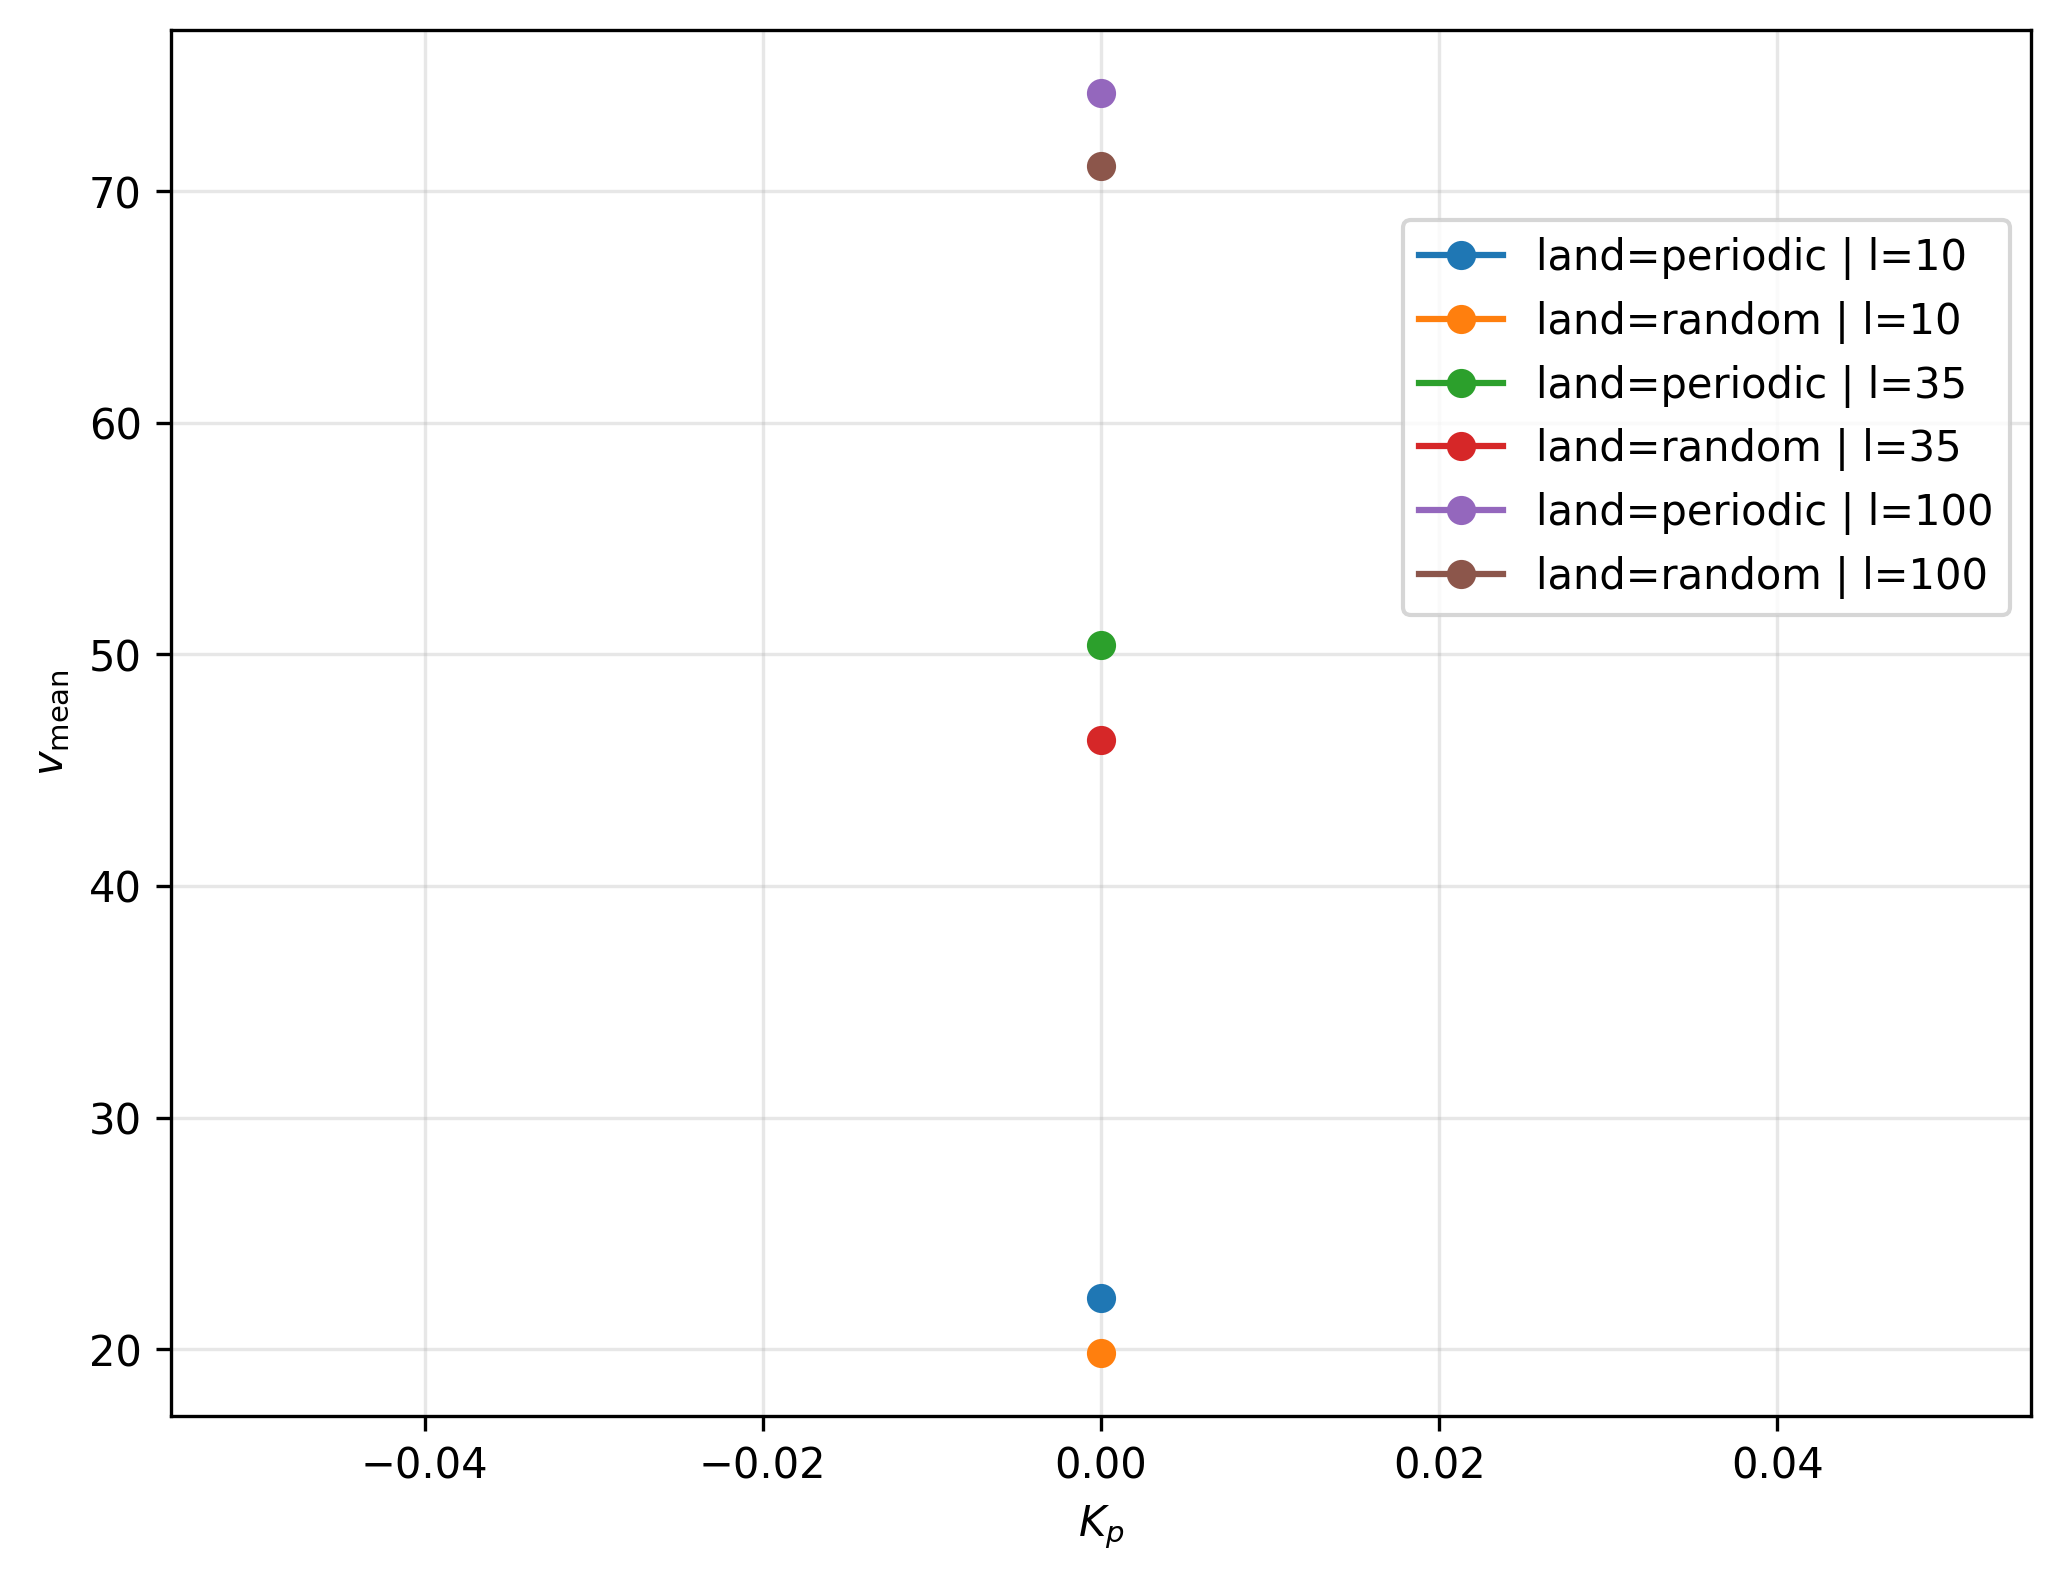

In [11]:
plt.figure(figsize=(8,6), dpi=300)

alphar = 0
landscapes = ["periodic", "random"]

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:

    for land in landscapes :

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("alphar") == alphar) &
            (pl.col("rrest") == rrest) &
            (pl.col("l") == l)
        )

        Kp      = df_land["Kp"].to_numpy()
        v_mean  = df_land["v_mean"].to_numpy()

        plt.plot(Kp, v_mean, label=f"land={land} | l={l}", marker = "o")

# plt.title(rf"$l={l}~|~\alpha_r = {alphar}$")
plt.xlabel(r"$\alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.72)
)
plt.show()


plt.figure(figsize=(8,6), dpi=300)

Kp = 0
ls = np.unique(df_passive["l"].to_numpy())

for l in ls:

    for land in landscapes :

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("Kp") == Kp) &
            (pl.col("l") == l)
        )

        alphar  = df_land["alphar"].to_numpy()
        v_mean  = df_land["v_mean"].to_numpy()

        plt.plot(alphar, v_mean, label=f"land={land} | l={l}", marker = "o")

# plt.title(rf"$l={l}~|~K_p = {Kp}$")
plt.xlabel(r"$K_p$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.72)
)
plt.show()

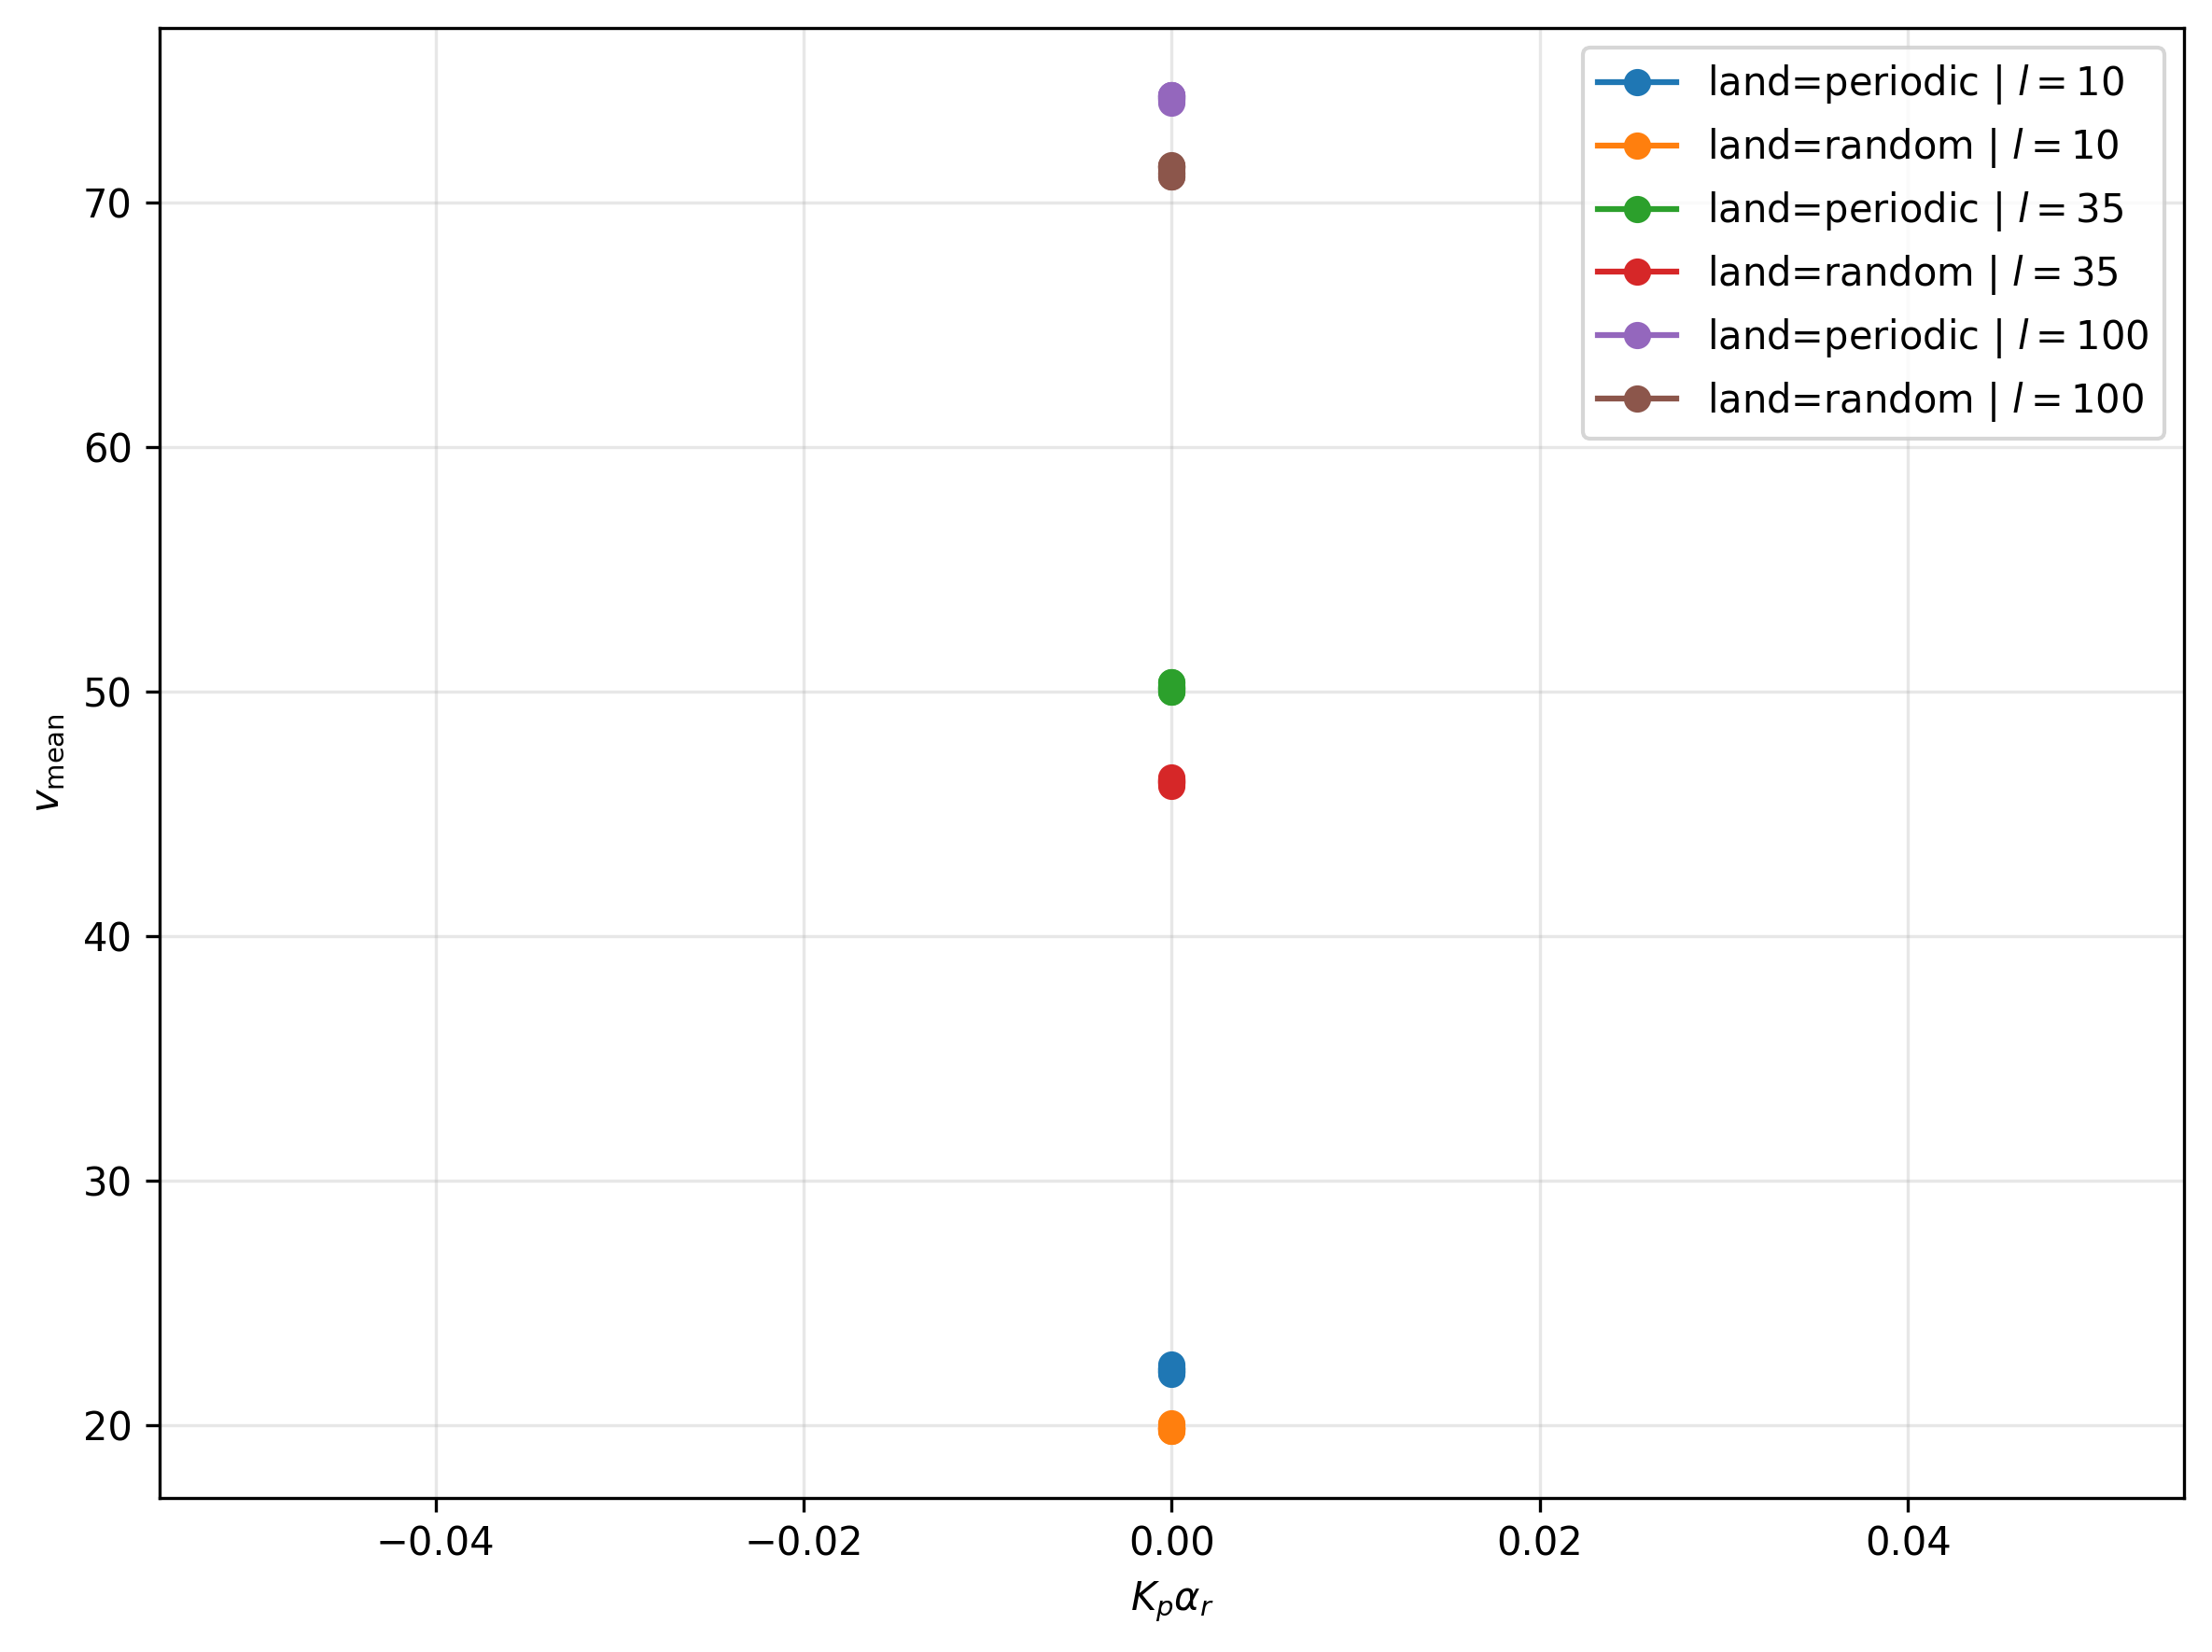

In [12]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean_land = df_land["v_mean"].to_numpy()

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_land[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
150 * (10/45) * 0.67

22.333333333333332

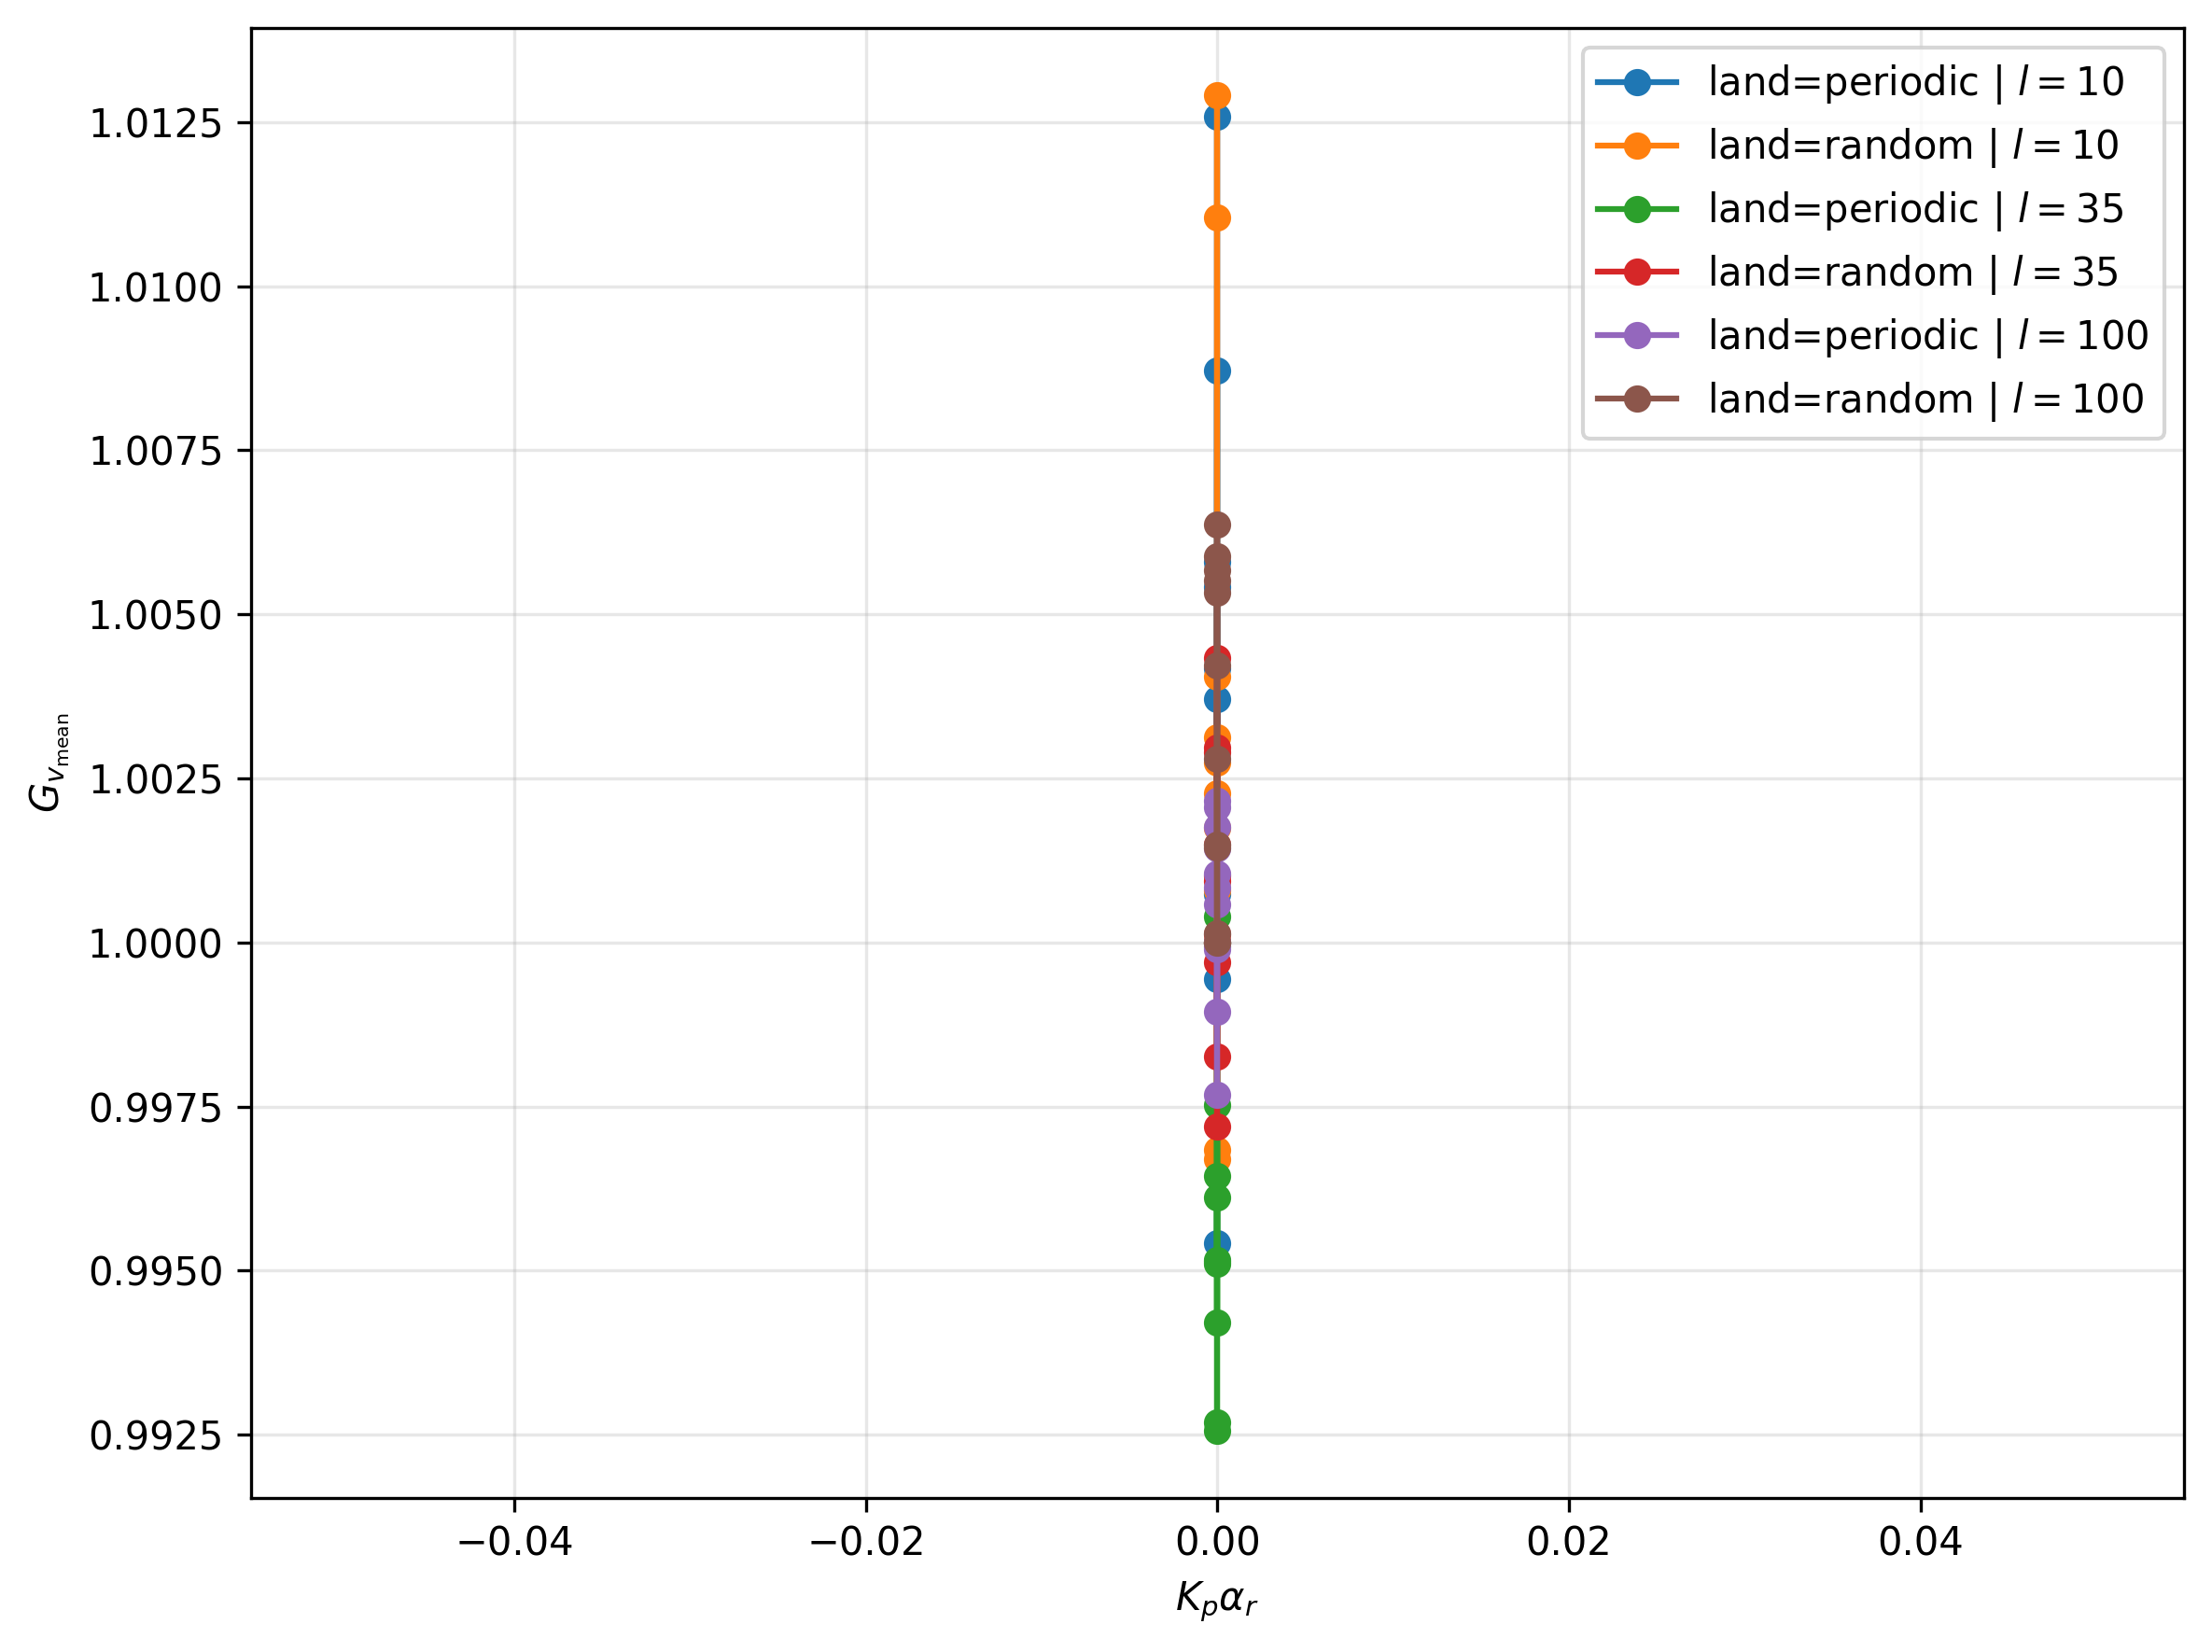

In [14]:
plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        v_base = df_passive.filter(
            (pl.col("alphar") == 0) &
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )["v_mean"].to_numpy()[0]

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        gain = df_land["v_mean"].to_numpy() / v_base

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            gain[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$G_{v_{\mathrm{mean}}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

# Passive : bp

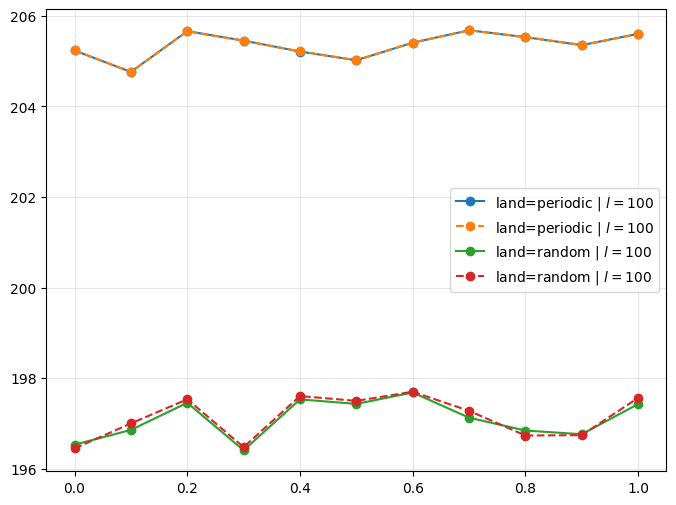

In [36]:
plt.figure(figsize=(8,6))

lands = ["periodic", "random"]

l = 100
alphac = 0.67
c_moyen = (150 + l) / (35 + l)

df_test = df_passive.filter(
    pl.col("l") == l
)

for land in lands :
    df_plot = df_test.filter(
        (pl.col("land") == land)
    )

    Kp      = df_plot["Kp"]
    vc_mean = df_plot["vc_mean"].to_numpy()
    vc_mean_equiv = df_plot["v_mean"].to_numpy() * c_moyen


    plt.plot(Kp, vc_mean / alphac, marker="o", label=f"land={land} | $l={l}$", ls="-")
    plt.plot(Kp, vc_mean_equiv / alphac, marker="o", label=f"land={land} | $l={l}$", ls="--")

plt.grid(True, alpha=0.30)
plt.legend()
plt.show()

[0.43343002 0.91999935 4.95832966 0.45593637 0.89865109 5.03761076
 0.51076363 0.81849765 5.0126527  0.50158119 0.88130592 4.9496217
 0.48977197 0.93121827 5.01796784 0.45288592 0.90461813 4.94689604
 0.51116581 0.87746673 4.87042098 0.48168624 0.94179234 4.98950856
 0.42053722 0.85875339 4.908477   0.48445613 0.91306544 4.9786264
 0.48973432 0.94791124 5.10661309]
[0.48276886 0.8574155  4.28628419 0.46871448 0.86721088 4.48949264
 0.51108897 0.87690307 4.51167431 0.45955848 0.86666262 4.37907656
 0.49795983 0.85156558 4.38831075 0.44668757 0.90321354 4.39262647
 0.47428489 0.83796389 4.50266932 0.47305559 0.93450081 4.58281277
 0.49069938 0.87707373 4.43406187 0.41801515 0.91077416 4.55749765
 0.51285503 0.88816298 4.37335785]


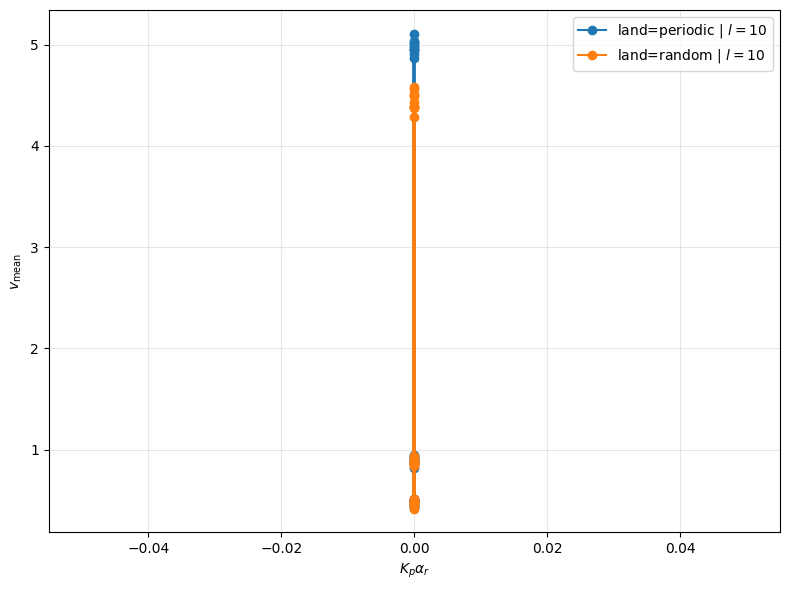

s=[35] | μ=[150] | θ=[100]


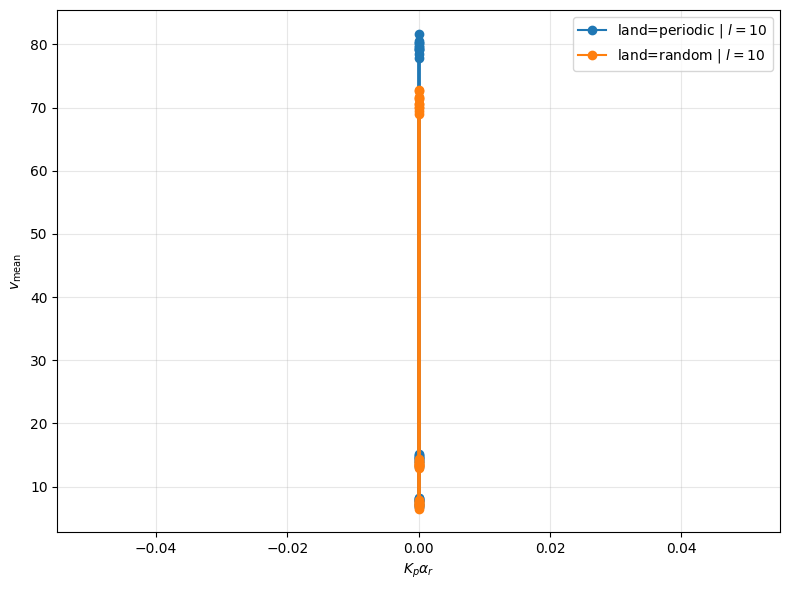

s=[35] | μ=[150] | θ=[100]


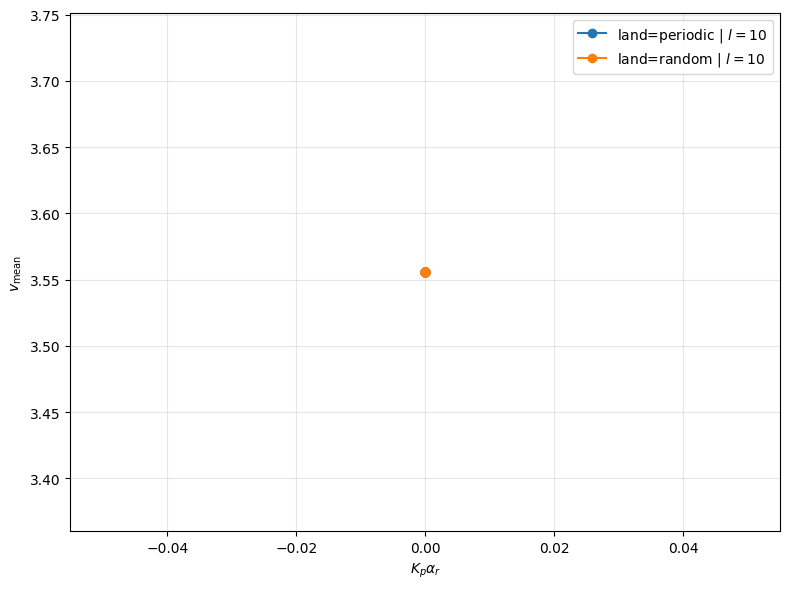

In [17]:
# -- Librairies
import matplotlib.pyplot as plt
import polars as pl
import numpy as np


# -- Second method
plt.figure(figsize=(8, 6))
ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean_land = df_land["vc_mean"].to_numpy()
        print(v_mean_land)

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_land[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()


# -- First method
plt.figure(figsize=(8, 6))
ls      = np.unique(df_passive["l"].to_numpy())
s       = np.unique(df_passive["s"].to_numpy())
mu      = np.unique(df_passive["mu"].to_numpy())
theta   = np.unique(df_passive["theta"].to_numpy())

print(f"s={s} | μ={mu} | θ={theta}")

for l in ls:

    c = (150 + l) / (35 + l)

    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean      = df_land["v_mean"].to_numpy()
        v_mean_c    = v_mean * c

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_c[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()    


# -- First method WITHOUT ALPHA C
plt.figure(figsize=(8, 6))
ls      = np.unique(df_passive["l"].to_numpy())
s       = np.unique(df_passive["s"].to_numpy())
mu      = np.unique(df_passive["mu"].to_numpy())
theta   = np.unique(df_passive["theta"].to_numpy())

print(f"s={s} | μ={mu} | θ={theta}")

for l in ls:

    c = (150 + l) / (35 + l)

    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean      = df_land["v_mean"].to_numpy()
        alphac     = df_land["v_mean"].to_numpy()
        v_mean_c    = v_mean * c / alphac

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_c[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()  

In [14]:
150 * 160/45 * 0.60

320.0

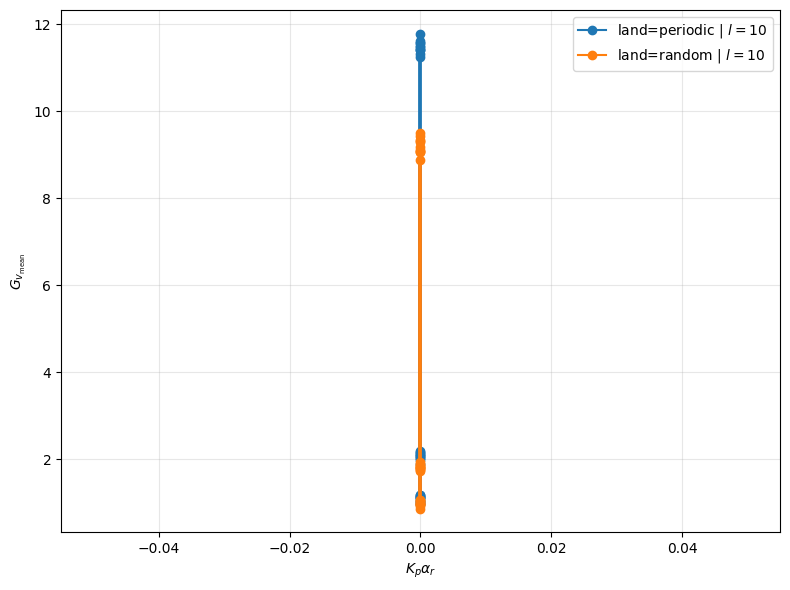

In [15]:
plt.figure(figsize=(8, 6))

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        v_base = df_passive.filter(
            (pl.col("alphar") == 0) &
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )["vc_mean"].to_numpy()[0]

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        gain = df_land["vc_mean"].to_numpy() / v_base

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            gain[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$G_{v_{\mathrm{mean}}}$")
plt.grid(True, alpha=0.30, which="both")
# plt.loglog(True)
plt.legend()
plt.tight_layout()
plt.show()

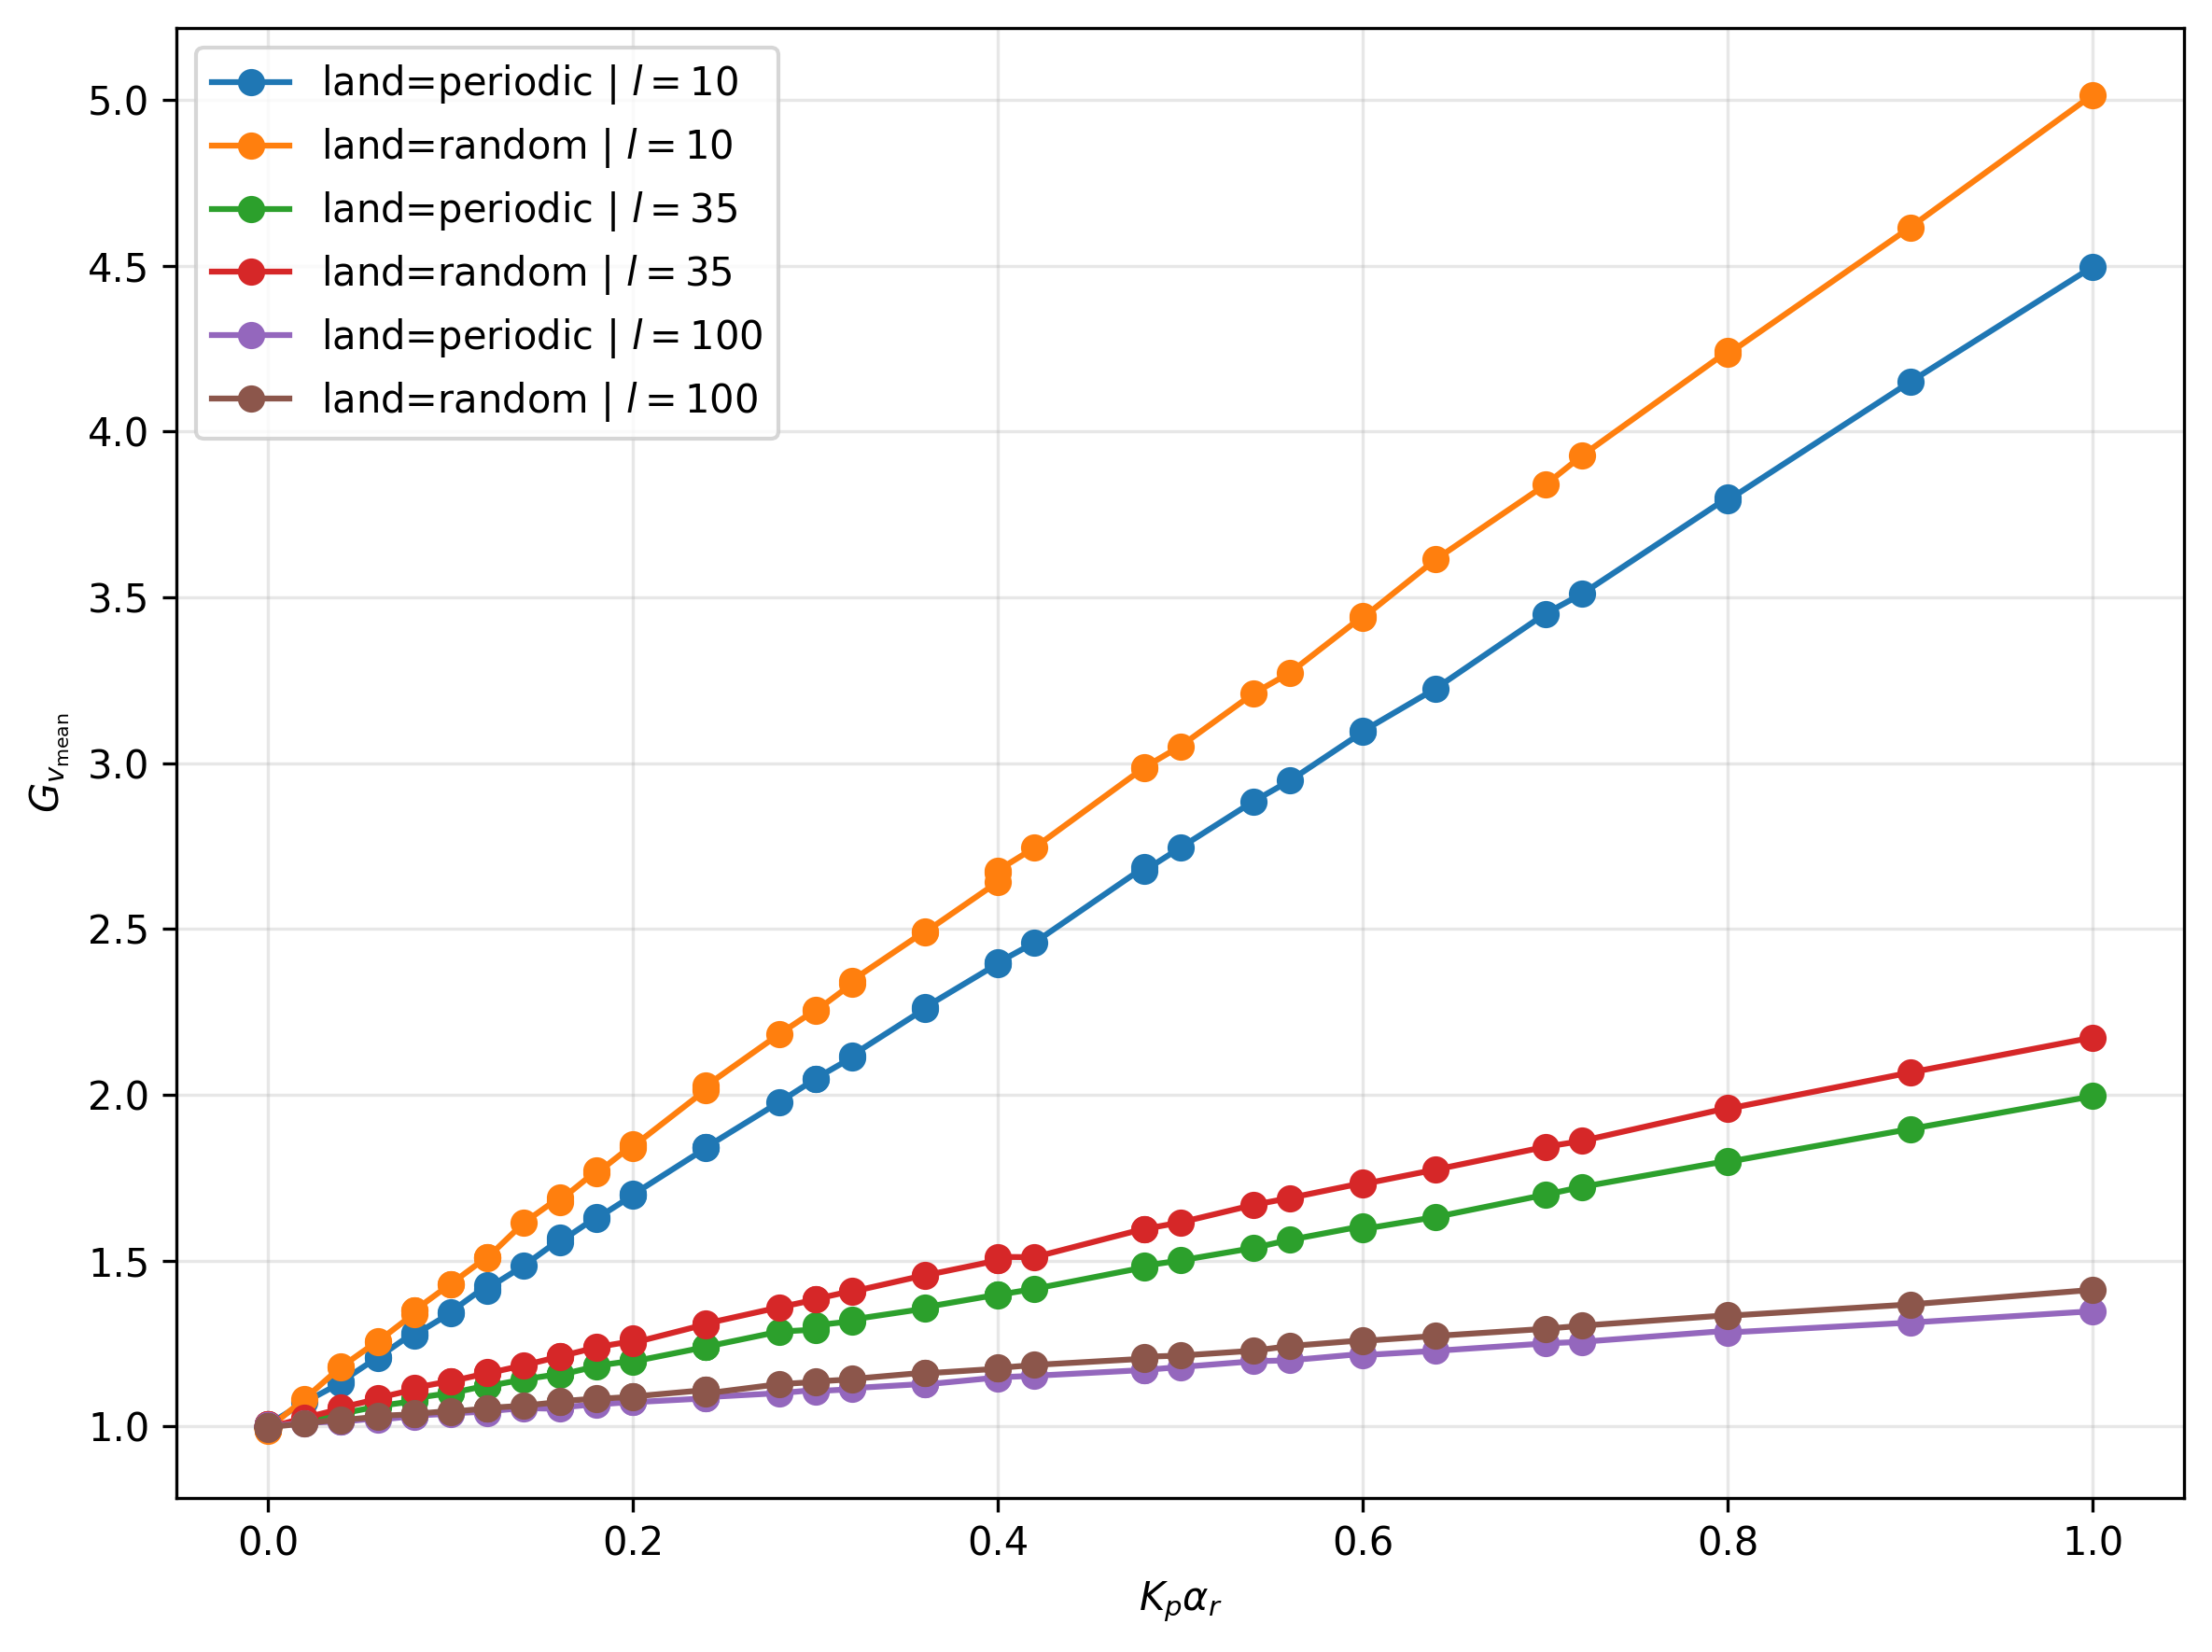

In [36]:
plt.figure(figsize=(8, 6), dpi=300)

ls      = np.unique(df_passive["l"].to_numpy())
s       = np.unique(df_passive["s"].to_numpy())
mu      = np.unique(df_passive["mu"].to_numpy())
theta   = np.unique(df_passive["theta"].to_numpy())

for l in ls:

    c = (150 + l) / (35 + l)

    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        v_base_c = df_passive.filter(
            (pl.col("alphar") == 0) &
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )["v_mean"].to_numpy()[0] * c

        v_mean_c = df_land["v_mean"].to_numpy() * c

        gain =  v_mean_c / v_base_c

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            gain[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$G_{v_{\mathrm{mean}}}$")
plt.grid(True, alpha=0.30)
plt.legend()
# plt.loglog(True)
plt.tight_layout()
plt.show()

# Active no mémo

In [26]:
# - Actifull -----
df_actifull = df_fact.filter(pl.col("mode") == "actifull")
print(df_actifull)

shape: (1_782, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 91.5  ┆ 0.999241 ┆ 0.837845 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 73.5  ┆ 0.996669 ┆ 0.836689 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 98.5  ┆ 0.998465 ┆ 0.838713 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 74.5  ┆ 1.001269 ┆ 0.840778 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 82.5  ┆ 1.000149 ┆ 0.839989 ┆ 0.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 90.5  ┆ 0.987432 ┆ 0.827666 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 78.5  ┆ 1.004093 ┆

In [27]:
columns = [
    'algo', 'fact', 'mode', 'dstr', 
    'land', 's', 'l', 'bpmin', 
    'mu', 'theta', 'alphaf', 
    'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 
    'alphar', 'krel', 'Kp', 'Kz'
]

for col in columns:
    print(f"Unique values of {col} : {np.unique(df_actifull[col])}")

landscapes = ["periodic", "random"]
df_actifull = df_actifull.filter(
    (pl.col("land").is_in(landscapes))
)
print(df_actifull)

Unique values of algo : ['2S']
Unique values of fact : [ True]
Unique values of mode : ['actifull']
Unique values of dstr : [False]
Unique values of land : ['homogen' 'periodic' 'random']
Unique values of s : [35]
Unique values of l : [ 10  35 100]
Unique values of bpmin : [0]
Unique values of mu : [150]
Unique values of theta : [100]
Unique values of alphaf : [1.]
Unique values of alphao : [0.]
Unique values of beta : [0.]
Unique values of rcapt : [2.]
Unique values of rrest : [2.]
Unique values of alphac : [0.6]
Unique values of alphad : [0.]
Unique values of alphar : [0.  0.2 0.4 0.6 0.8 1. ]
Unique values of krel : [1.]
Unique values of Kp : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Unique values of Kz : [0.  0.5 1. ]
shape: (1_188, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool 

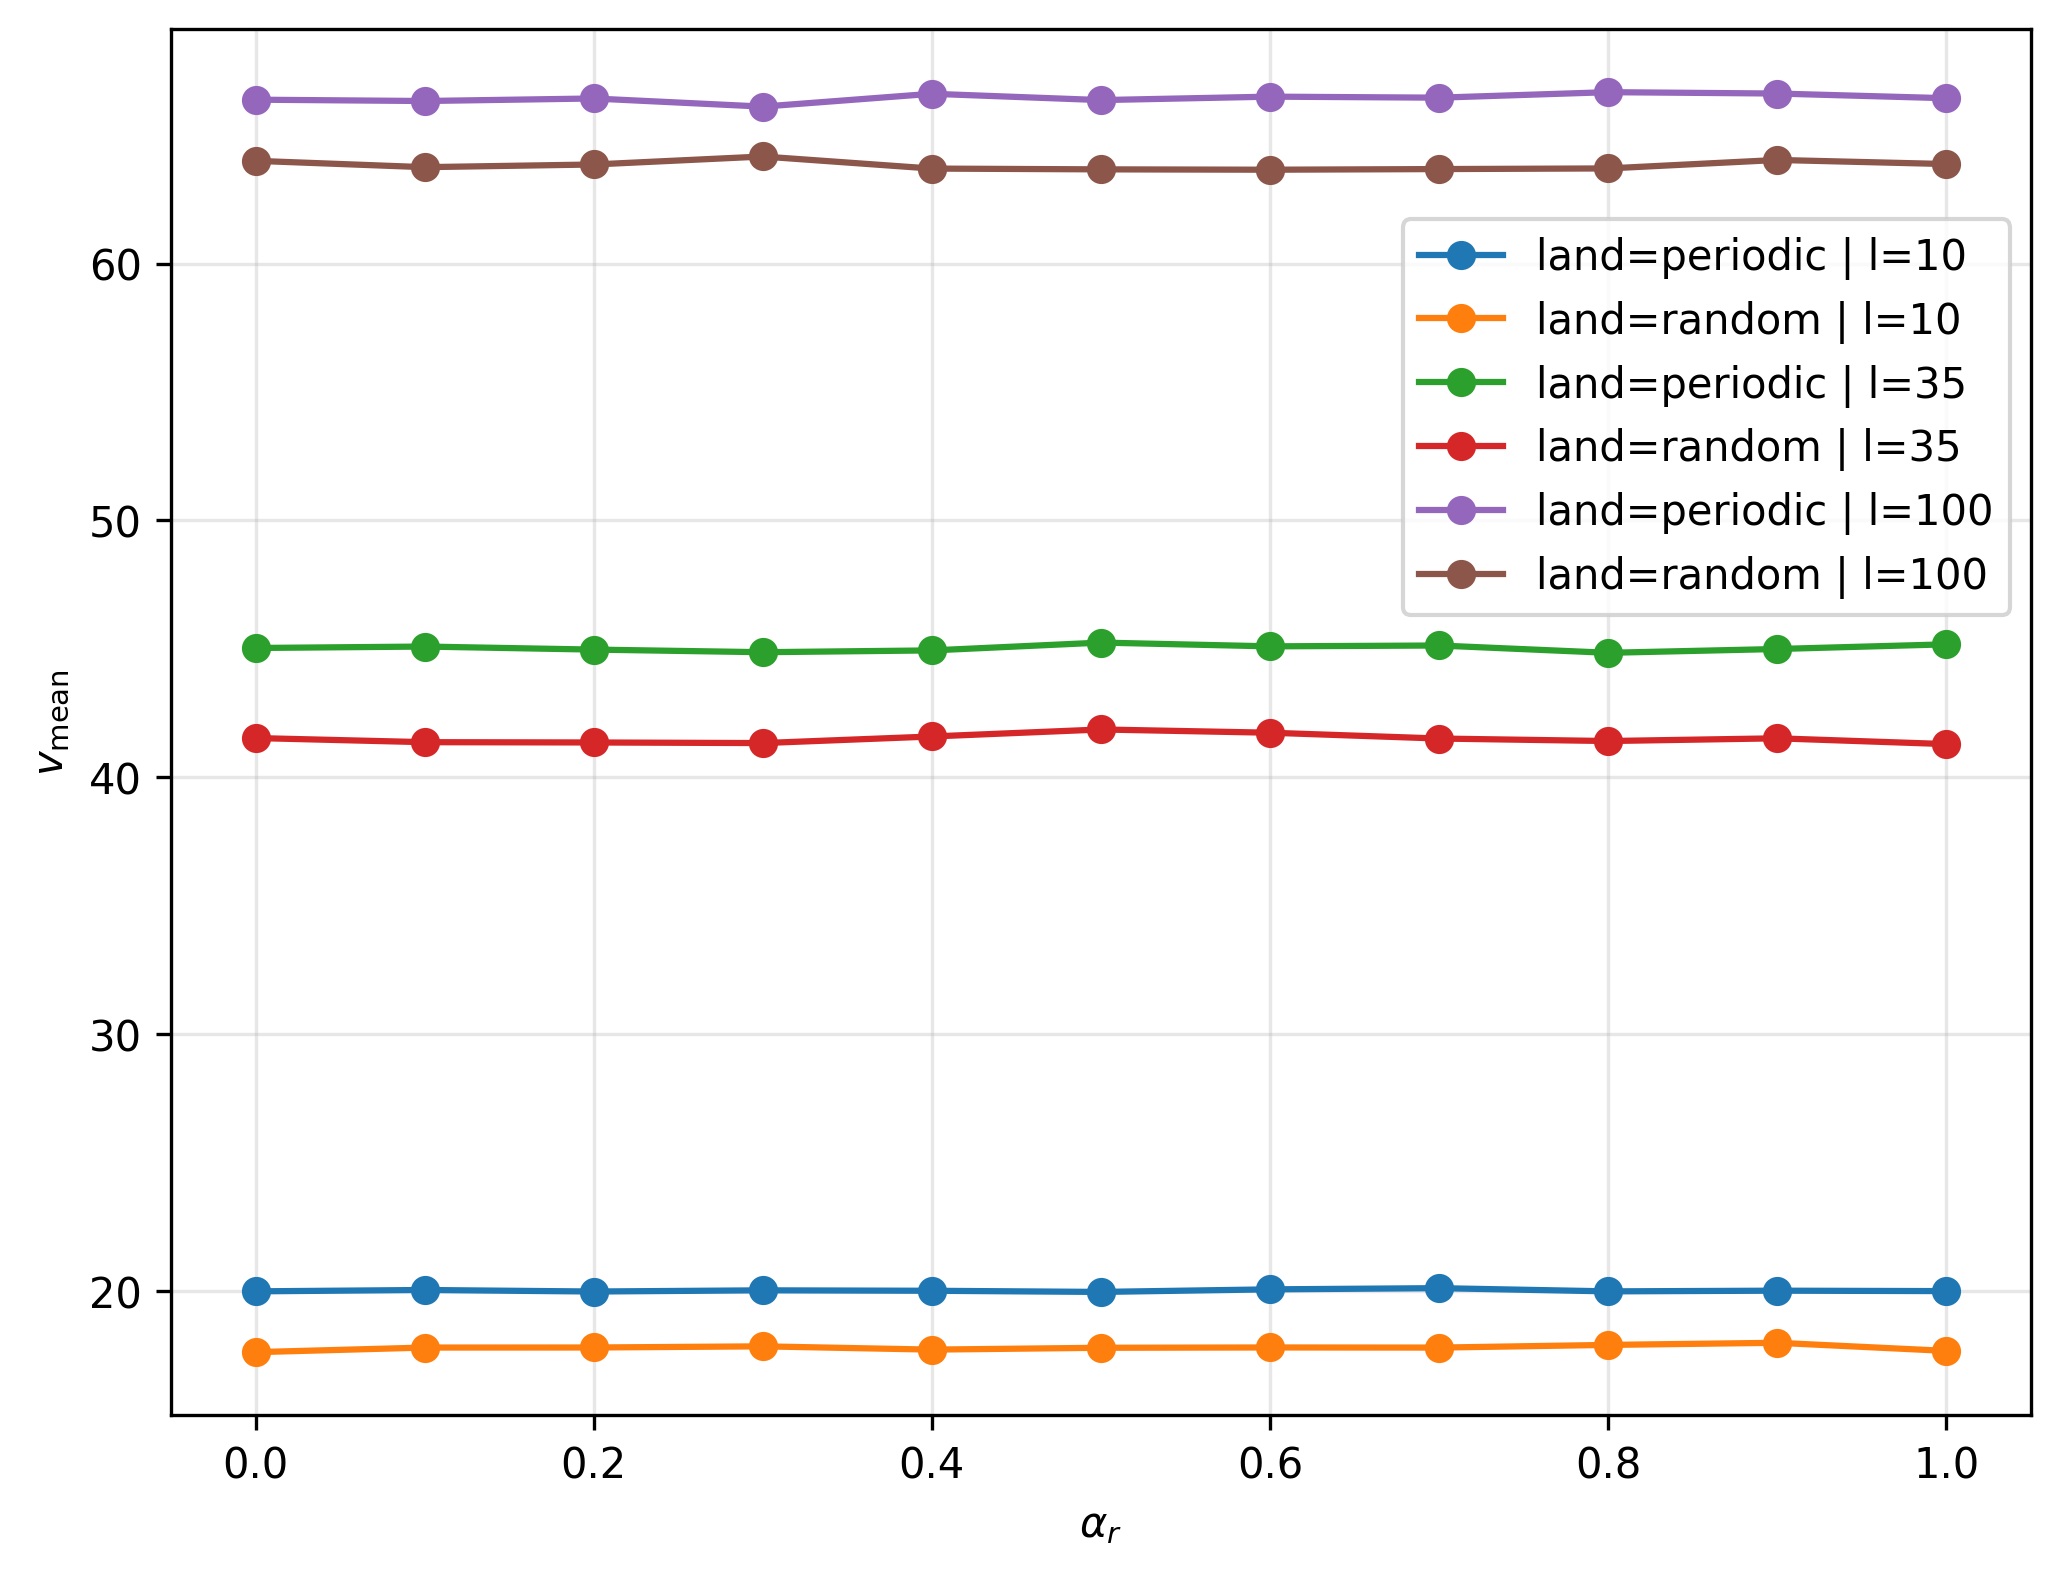

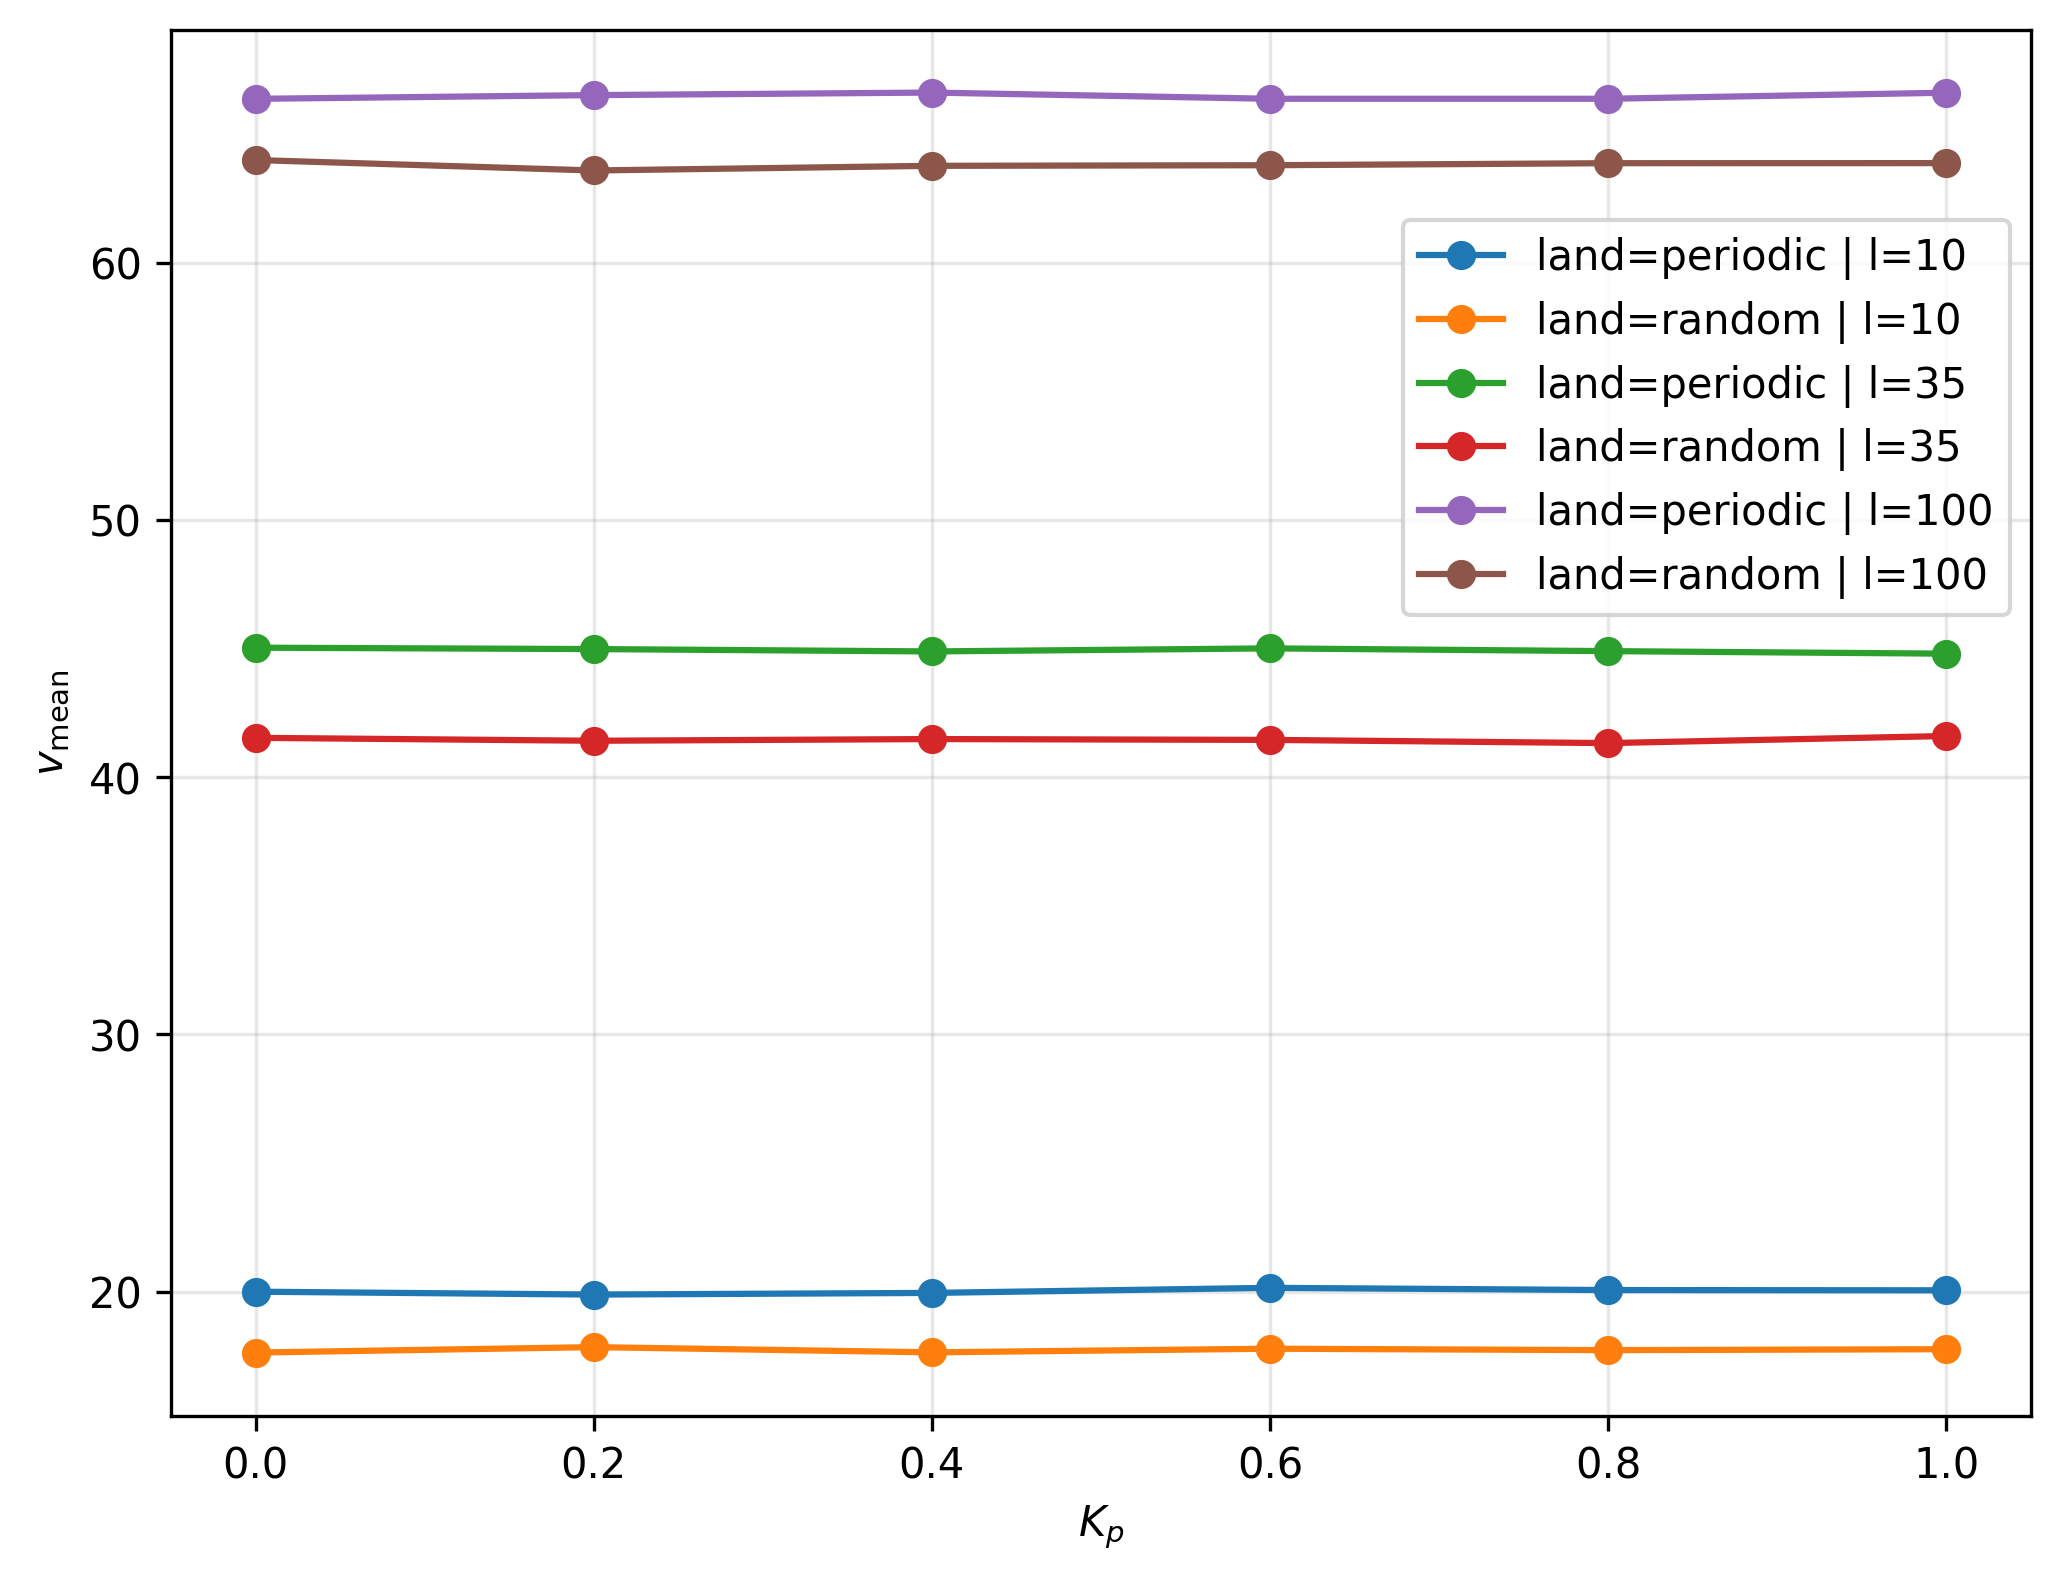

In [28]:
plt.figure(figsize=(8,6), dpi=300)

alphar = 0

ls = np.unique(df_actifull["l"].to_numpy())

for l in ls:

    for land in landscapes :

        df_land = df_actifull.filter(
            (pl.col("land") == land) &
            (pl.col("alphar") == alphar) &
            (pl.col("l") == l) &
            (pl.col("Kz") == 0)
        )

        Kp      = df_land["Kp"].to_numpy()
        v_mean  = df_land["v_mean"].to_numpy()

        plt.plot(Kp, v_mean, label=f"land={land} | l={l}", marker = "o")

# plt.title(rf"$l={l}~|~\alpha_r = {alphar}$")
plt.xlabel(r"$\alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.72)
)
plt.show()


plt.figure(figsize=(8,6), dpi=300)

Kp = 0
ls = np.unique(df_actifull["l"].to_numpy())

for l in ls:

    for land in landscapes :

        df_land = df_actifull.filter(
            (pl.col("land") == land) &
            (pl.col("Kp") == Kp) &
            (pl.col("l") == l) &
            (pl.col("Kz") == 0)
        )

        alphar  = df_land["alphar"].to_numpy()
        v_mean  = df_land["v_mean"].to_numpy()

        plt.plot(alphar, v_mean, label=f"land={land} | l={l}", marker = "o")

# plt.title(rf"$l={l}~|~K_p = {Kp}$")
plt.xlabel(r"$K_p$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.72)
)
plt.show()

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 

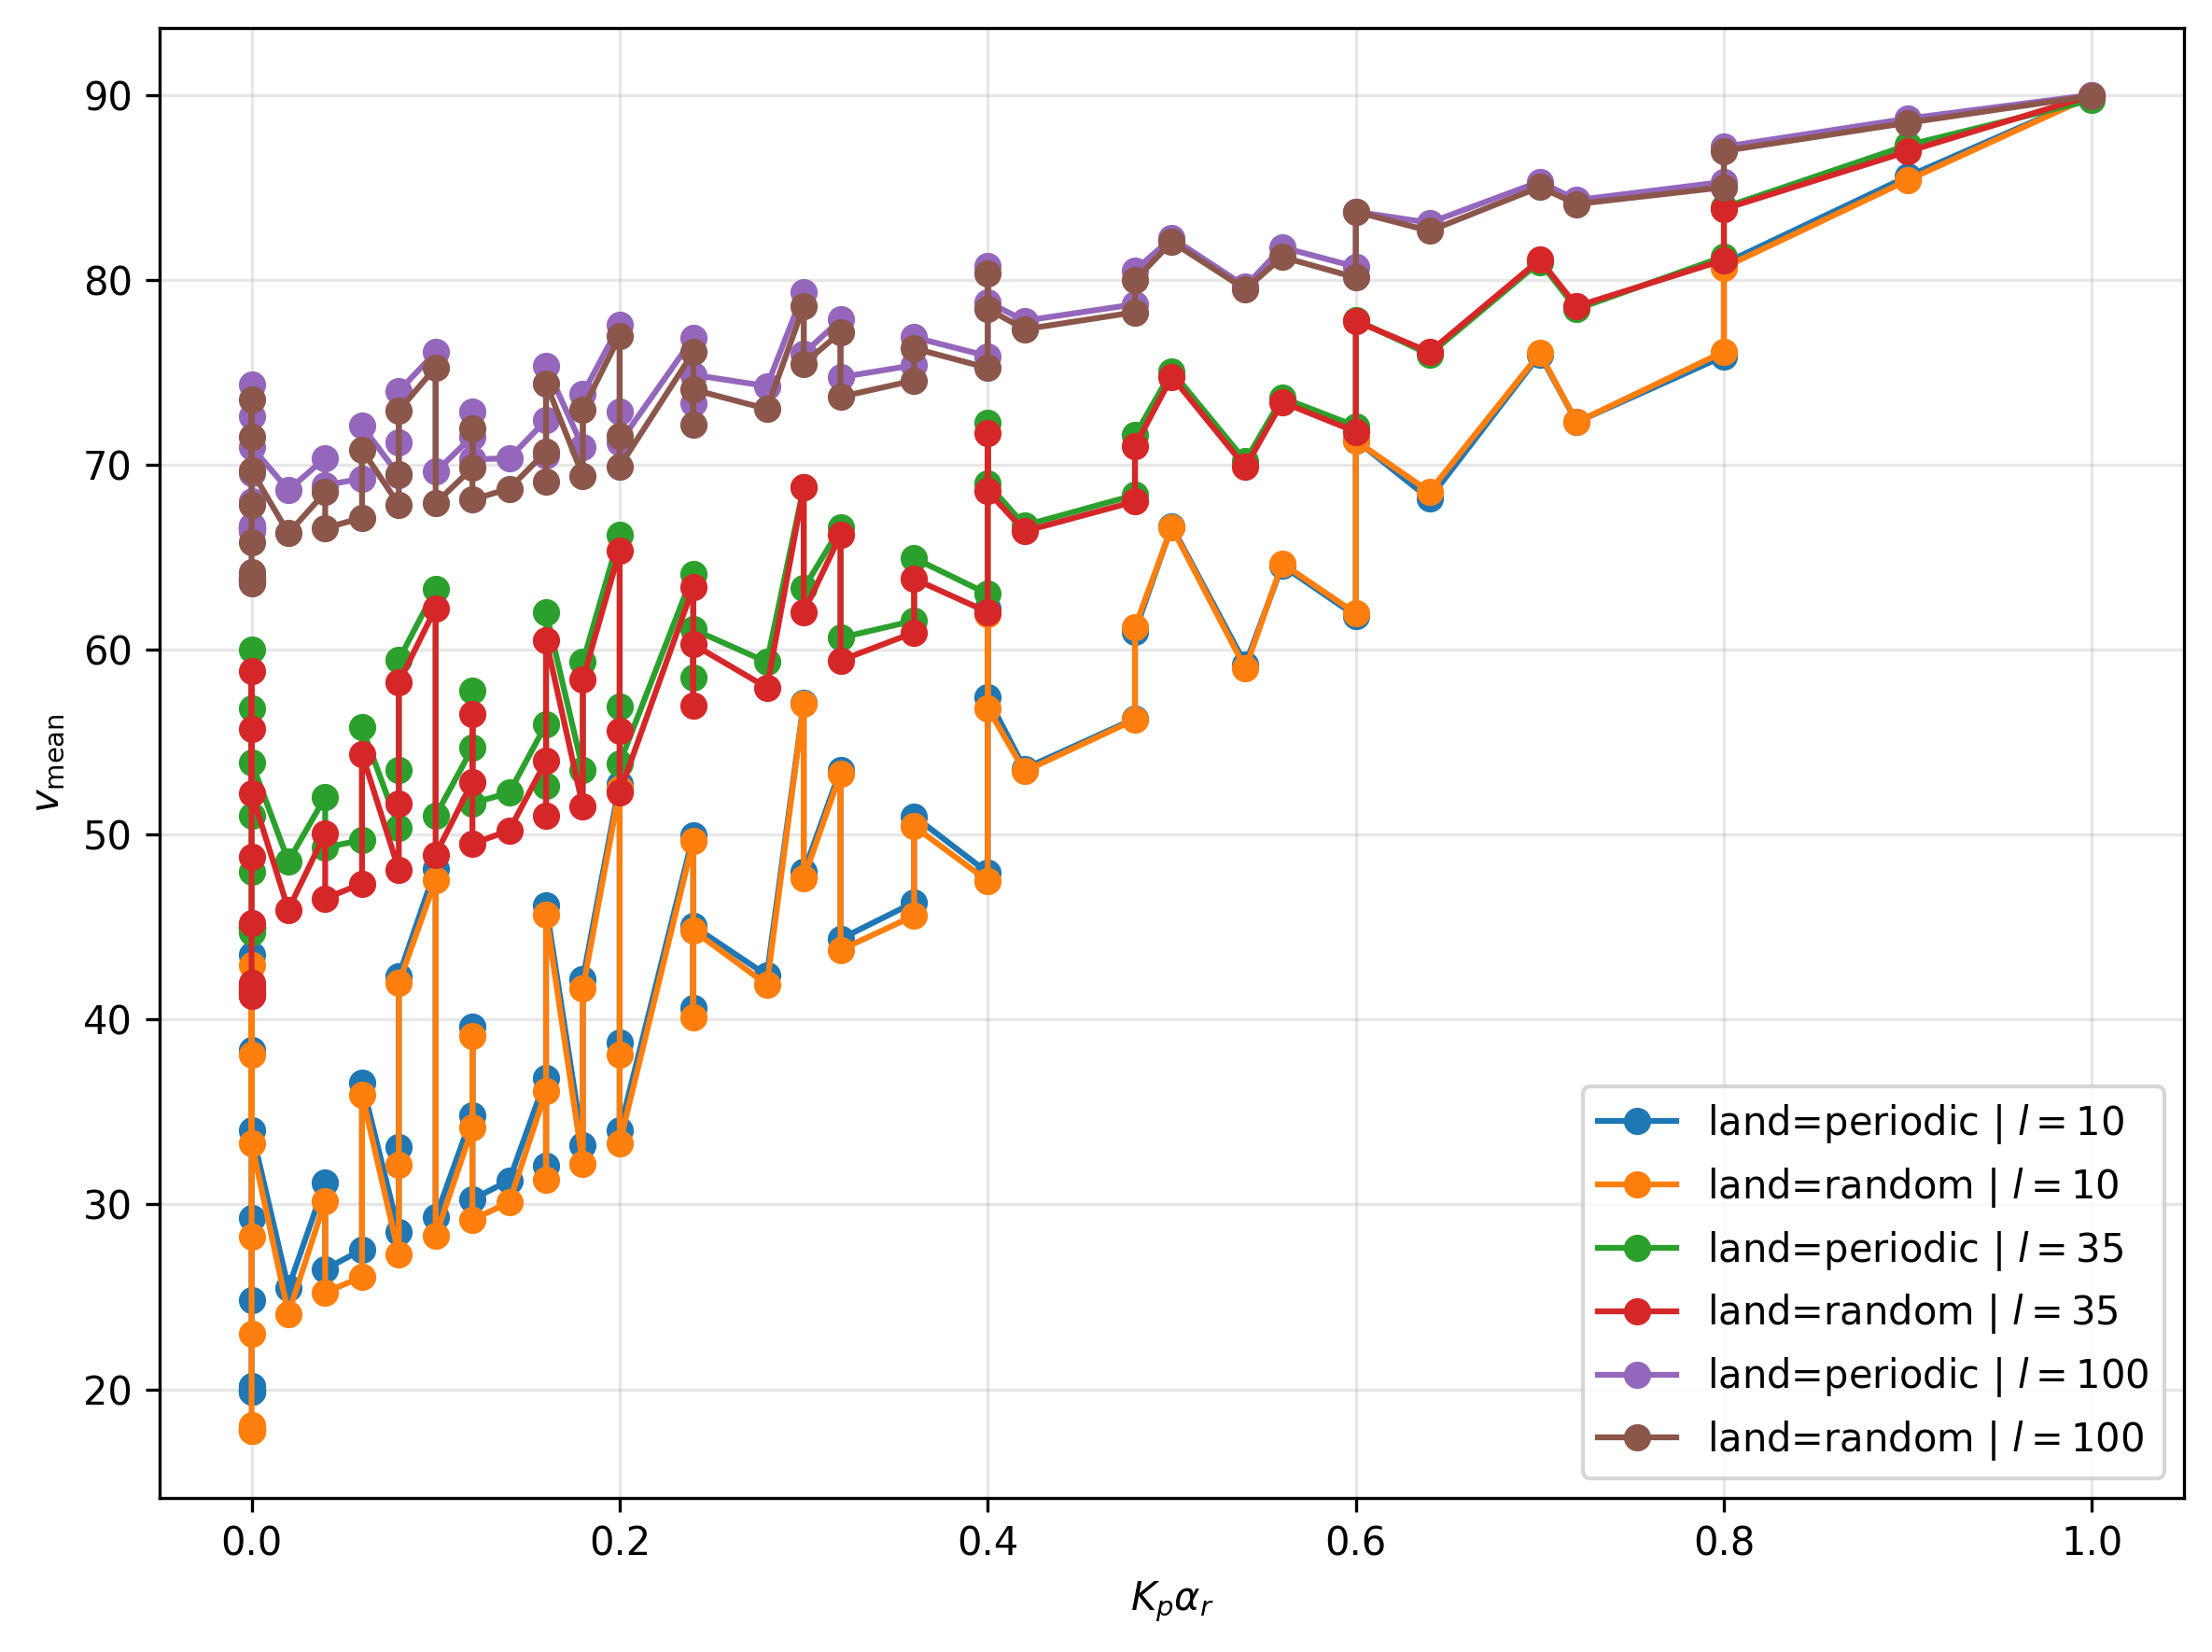

In [ ]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_actifull.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l) &
            # (pl.col("alphar") == 1) &
            (pl.col("Kz") == 1)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean_land = df_land["v_mean"].to_numpy()

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_land[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

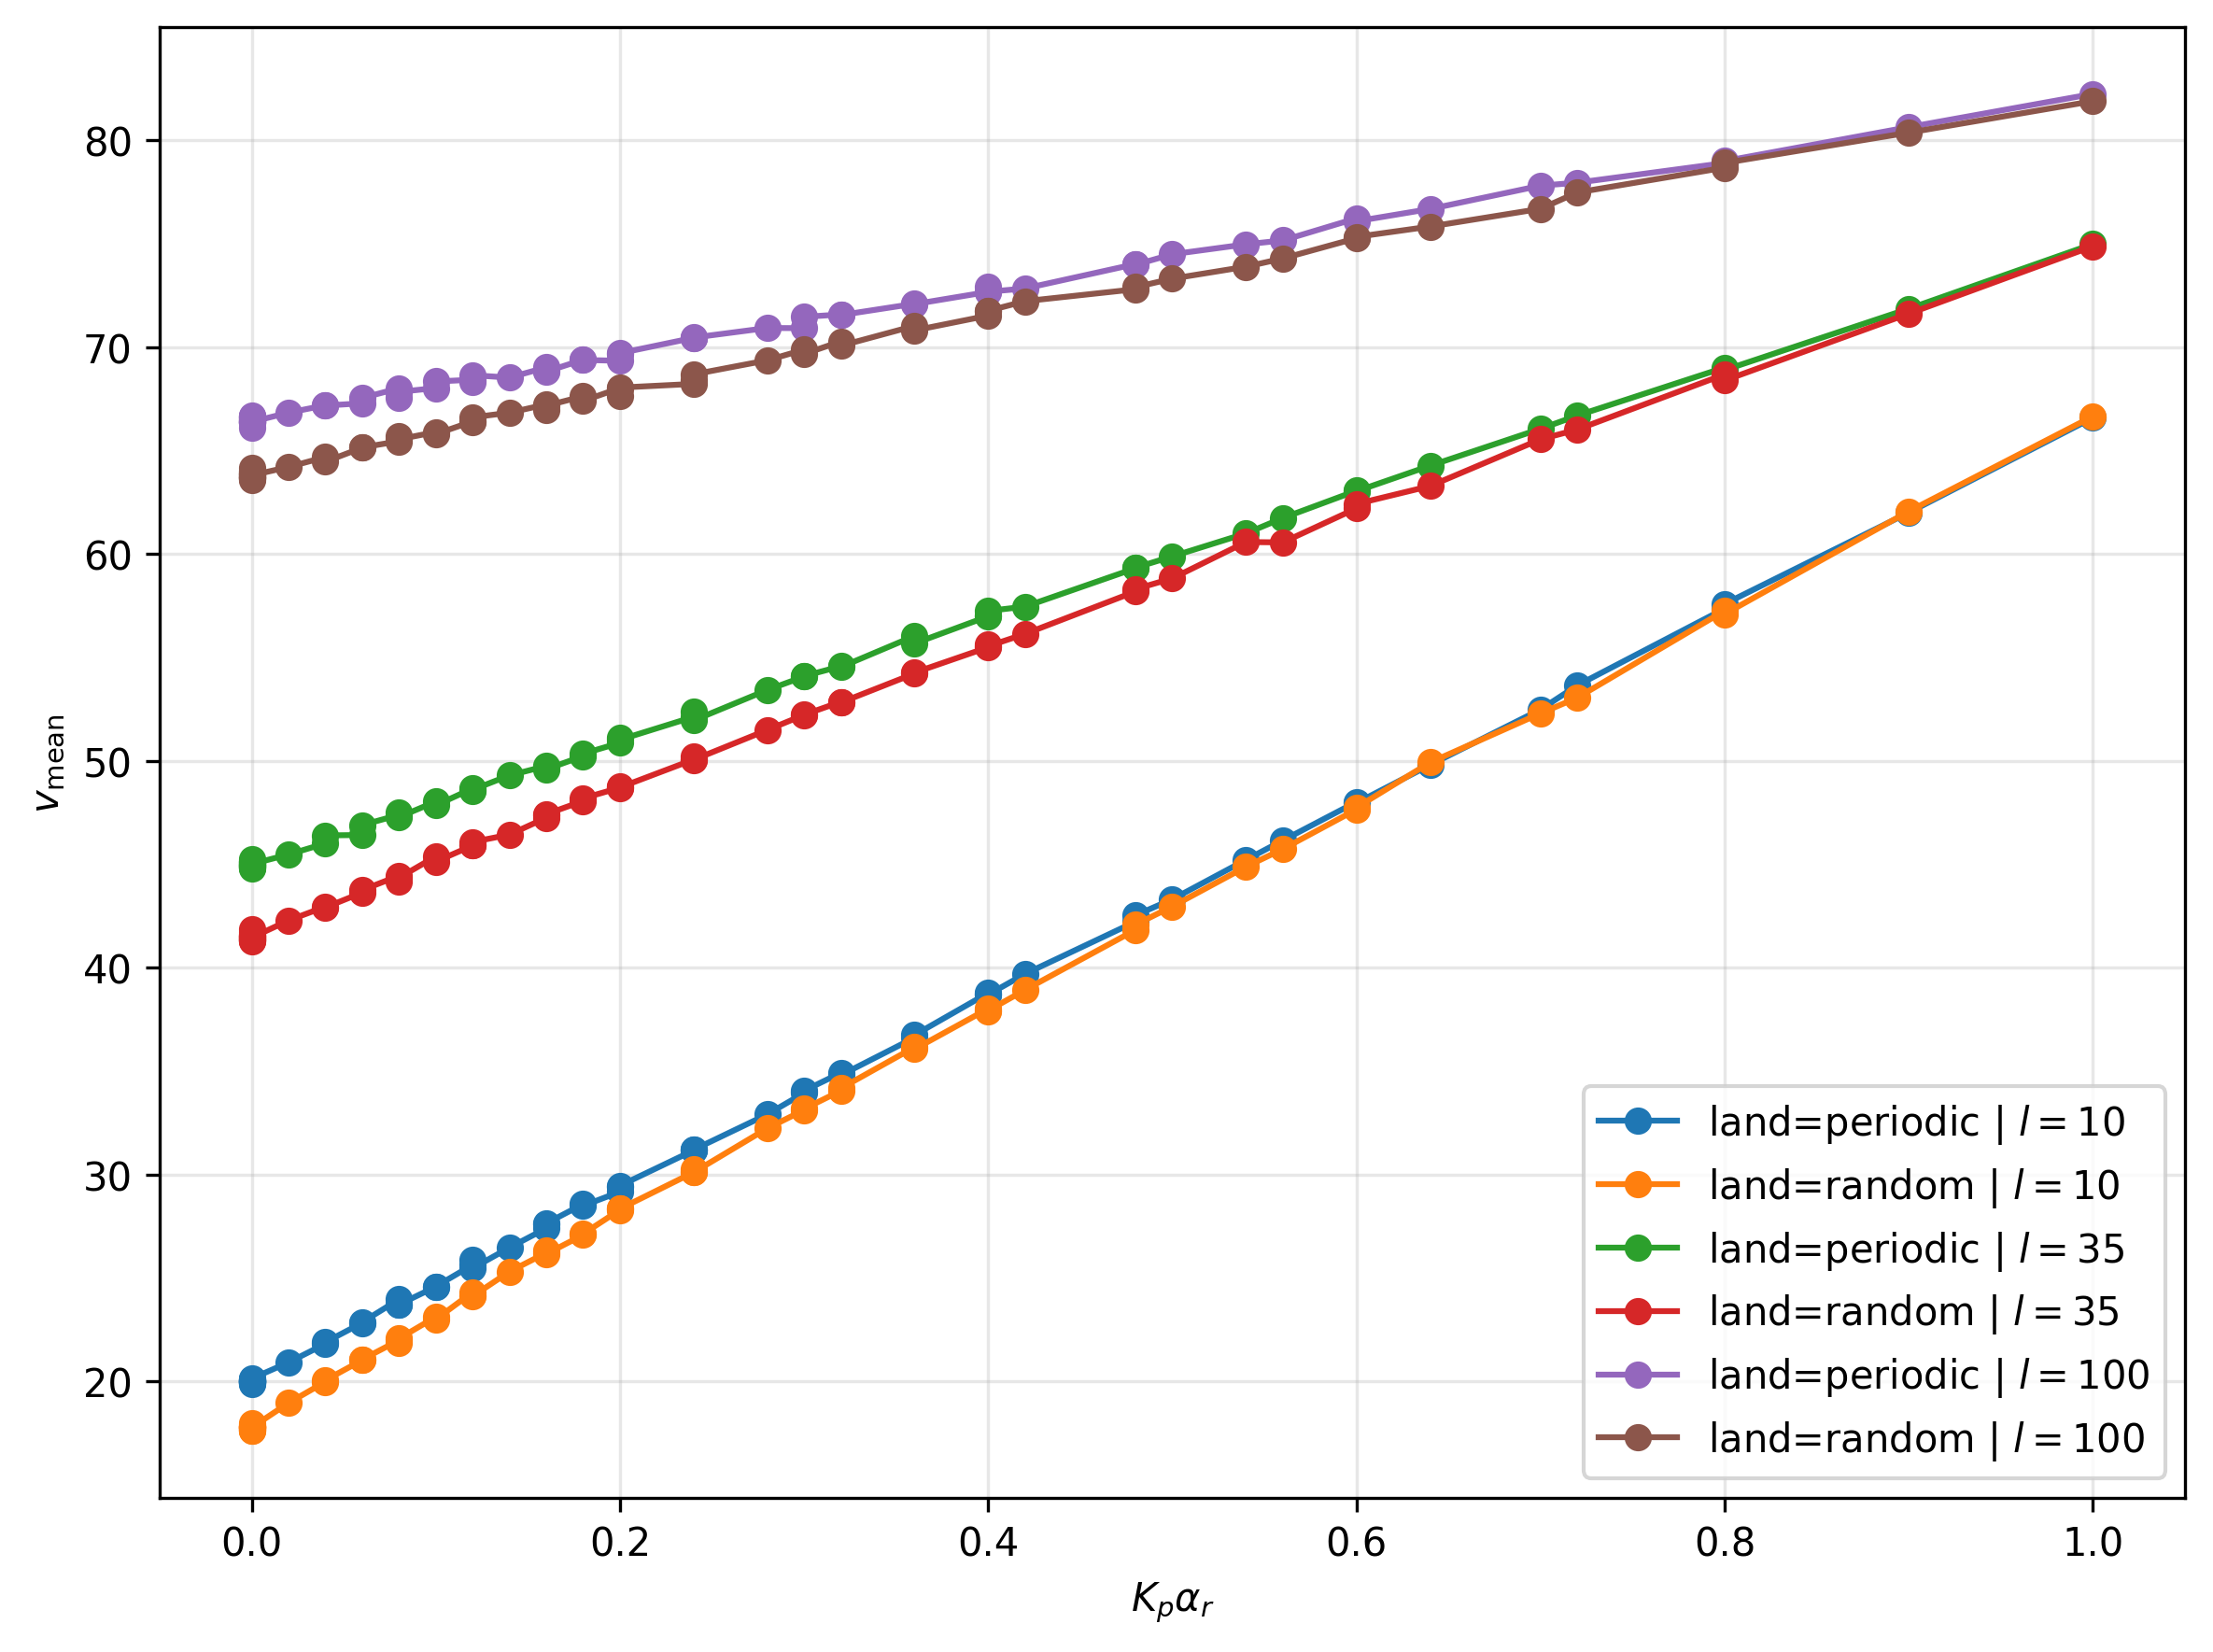

In [43]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_actifull["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_actifull.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l) &
            (pl.col("Kz") == 0)
            # (pl.col("Kp") == 1)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean_land = df_land["v_mean"].to_numpy()

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_land[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
# Librairies
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from nucleo.io.reading import reading_all_parquet

# Racine
root_work = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PC__2026-09-15/"

# # Charge tout
# lazy_work = pl.scan_parquet(
#     f"{root_work}/**/**/*.parquet"
# )
# df_work = lazy_work.collect()

# Charge que les Float / Int / Str
df_work = reading_all_parquet(root_work)

print(df_work)

columns = [
    'algo', 'fact', 'mode', 'dstr', 
    'land', 's', 'l', 'bpmin', 
    'mu', 'theta', 'alphaf', 
    'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 
    'alphar', 'krel', 'Kp', 'Kz'
]

for col in columns:
    print(f"Unique values of {col} : {np.unique(df_work[col])}")
print(df_work.columns)

shape: (594, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 179.5 ┆ 10.11455 ┆ 6.778    ┆ 1.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 89.5  ┆ 5.347406 ┆ 3.603624 ┆ 1.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 45.5  ┆ 1.00922  ┆ 0.836121 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 44.5  ┆ 8.60599  ┆ 6.250626 ┆ 2.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 135.5 ┆ 5.441    ┆ 4.046371 ┆ 2.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 102.5 ┆ 5.556951 ┆ 4.127068 ┆ 1.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 93.5  ┆ 0.988511 ┆ 0

/home/nicolas/Documents/Workspace/nucleo/src/nucleo/io/reading.py:143: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = _scalar_column_names(lf.schema)


shape: (22, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 89.5  ┆ 0.972708 ┆ 0.81875  ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 91.5  ┆ 0.981328 ┆ 0.848793 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 136.5 ┆ 1.03791  ┆ 0.849883 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 90.5  ┆ 0.99707  ┆ 0.849274 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 87.5  ┆ 0.985914 ┆ 0.840157 ┆ 0.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 47.5  ┆ 0.993134 ┆ 0.82539  ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 47.5  ┆ 0.981859 ┆ 0.

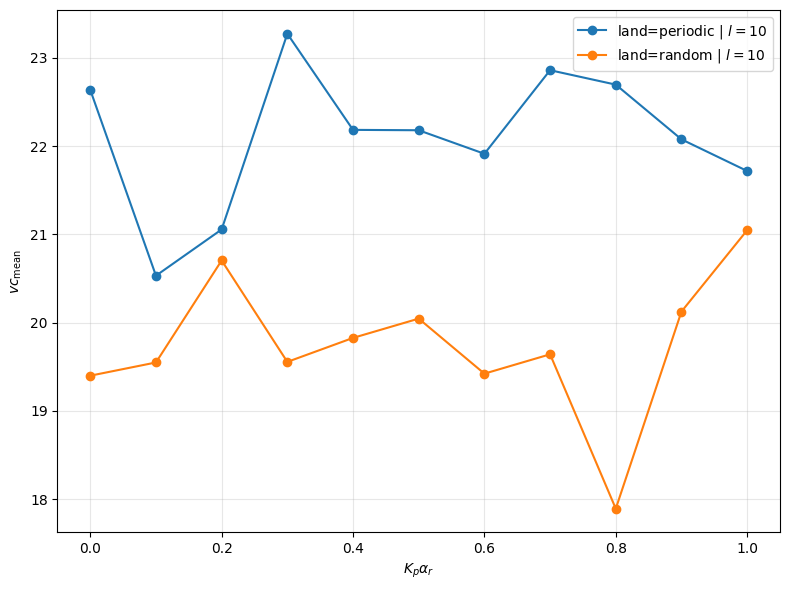

In [ ]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

plt.figure(figsize=(8, 6))

df_work_passive = df_work.filter(
    (pl.col("mode")  == "passfull") &
    (pl.col("rrest") == 2.00) &
    (pl.col("Kz") == 0.00)
)

print(df_work_passive)

ls = np.unique(df_work_passive["l"].to_numpy())
lands = np.unique(df_work_passive["land"].to_numpy())
print(ls, lands)

for l in ls:
    for land in lands:

        df_land = df_work_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l) 
            # (pl.col("alphar") == 1) &
        )
        
        Kp = df_land["Kp"].to_numpy()
        v_mean = df_land["v_mean"].to_numpy()


        plt.plot(
            Kp,
            v_mean,
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$vc_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

# Active mémo

In [14]:
# - Actifull -----
df_actimemo = df_fact.filter(pl.col("mode") == "actimemo")
print(df_actimemo)

shape: (1_782, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 76.5  ┆ 1.001531 ┆ 0.842224 ┆ 0.5   │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 74.5  ┆ 1.000219 ┆ 0.840694 ┆ 0.5   │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 81.5  ┆ 1.001264 ┆ 0.839951 ┆ 0.5   │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 72.5  ┆ 0.998398 ┆ 0.837447 ┆ 0.5   │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 89.5  ┆ 0.995786 ┆ 0.835434 ┆ 0.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 94.5  ┆ 0.987547 ┆ 0.82749  ┆ 0.5   │
│ 2S   ┆ true ┆ actimemo ┆ false ┆ … ┆ 98.5  ┆ 1.000654 ┆

# .